In [131]:
import os
import pandas as pd
import numpy as np
import pickle

import torch
import torch.nn.functional as F

import networkx as nx

import csv

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)  # To display full content of each column

# (1) global ppi

In [ ]:
# from code/contextual_gnn/external_PPI/v7_PPIs/merge_external_PPI_human_proteins_Dec18_2024.R

scp '/Users/apple/Penn Dropbox/Xiaochen Yang/exome/summary/contexual_gnn/WGCNA/external_vs_ukbppp/comparison/tmp6/string_otar_biogrid_hippie_huri_menche_and_more_all_merged_ppi_human_proteins.csv' yang1641@gilbreth.rcac.purdue.edu:/scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks/

In [4]:
os.chdir('/scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks')

global_ppi = pd.read_csv('string_otar_biogrid_hippie_huri_menche_and_more_all_merged_ppi_human_proteins.csv')
print(global_ppi.shape)
global_ppi.head()

(1758460, 4)


,protein1,protein2,edge_dir,ppi
0,APEX1,3BP2,directed,merged
1,BRD2,3BP2,directed,merged
2,3BP2,CBL,directed,merged
3,CD244,3BP2,directed,merged
4,3BP2,DBNL,directed,merged


In [10]:
protein1_and_protein2 = pd.concat([global_ppi['protein1'], global_ppi['protein2']], axis=0)
print(protein1_and_protein2.shape)
print(protein1_and_protein2.nunique())

(3516920,)
23363


consider manually removing one protein or renaming it

In [13]:
global_ppi.loc[
    (global_ppi['protein1'].isin(['BCR/ABL FUSION'])) | global_ppi['protein2'].isin(['BCR/ABL FUSION'])
]

,protein1,protein2,edge_dir,ppi
254051,BCR/ABL FUSION,GRB2,directed,merged


In [11]:
# global_ppi[['protein1', 'protein2']].to_csv(
#     'string_otar_biogrid_hippie_huri_menche_and_more_all_merged_ppi_human_proteins.txt', 
#     sep = ' ', index = False, header = False#, quoting=csv.QUOTE_ALL
# )

In [15]:
global_ppi[['protein1', 'protein2']].loc[
    ~(global_ppi['protein1'].isin(['BCR/ABL FUSION'])) & ~(global_ppi['protein2'].isin(['BCR/ABL FUSION']))
].to_csv(
    'string_otar_biogrid_hippie_huri_menche_and_more_all_merged_ppi_human_proteins.txt', 
    sep = ' ', index = False, header = False#, quoting=csv.QUOTE_ALL
)

# (2) disease-specific ppi

# (3) disease-disease edge list (mg_edgelist.txt for mg_f)

https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/Z6H1A8

In [ ]:
scp -r '/Users/apple/Penn Dropbox/Xiaochen Yang/exome/data/disease_embedding' yang1641@gilbreth.rcac.purdue.edu:/scratch/gilbreth/yang1641/exome/data/

In [16]:
os.chdir('/scratch/gilbreth/yang1641/exome/data/disease_embedding/unified_clinical_vocabulary_embeddings')

os.listdir()

['new_node_map_df.csv',
 'full_h_embed_hms.csv',
 'new_homo_hg_hms.pt',
 'full_h_embed_hms.pkl',
 'full_h_embed_hms_phecode_df.tsv',
 'ttd_phecode_clinical_embed.tsv',
 'full_h_embed_hms_phecode_cosine_similarity_df.csv']

In [17]:
with open('full_h_embed_hms.pkl', 'rb') as f:
    full_h_embed_hms = pickle.load(f)

In [18]:
type(full_h_embed_hms)

torch.Tensor

In [19]:
full_h_embed_hms.shape

torch.Size([67124, 128])

In [20]:
full_h_embed_hms[0,:]

tensor([-11.5240,  -4.4478,   4.9922,   3.9199,   9.0145,  -0.3475,  -1.4488,
          7.3581,   7.5063,   6.5307,  -0.6514,  -7.1124,  -2.7013,  -4.4634,
          2.0344,   5.3753,   0.1471,   2.9896,  -0.5015, -12.6474, -10.9586,
         -6.2033, -10.4210,   3.1156,   4.9269,  -6.5938,   1.0421,  -8.2769,
         11.4274,   8.1124,  -4.2114,  -9.0993,  -7.5051,   5.5084,   4.9454,
         -1.6977,  -5.2862,  -3.2720,  -0.8753,  -0.5235,  -3.6309,  -0.6919,
         -3.8520,   5.2467,   8.1702,   3.5939,  -7.5289,   1.1691,  -0.0975,
          2.3934,   7.4032,   1.3745,  -0.7143,  -9.7454,  -6.3367,   4.0387,
         -0.4216,  -3.9968, -11.5196, -11.2886,  -8.6451,   8.6508,   5.5628,
          4.7875,  -7.7098,  -7.0363,   2.2633,   0.3414,  -9.2907,   2.2621,
         -4.8399,   0.4203,  10.9203, -13.6124,  -9.0434,   5.4867,  -8.7334,
          4.6430,  -1.7489,   2.4105,  -7.8412,   8.5838,   3.2805,  -2.8291,
          0.7501,  -0.6128,   0.0505,  -4.3946,  -8.4255,  -8.15

In [21]:
full_h_embed_hms

tensor([[-11.5240,  -4.4478,   4.9922,  ...,   3.4217,   4.8128,   0.2533],
        [ -2.3434,  -1.3455,   2.8129,  ...,   9.3298,  -3.3438,   2.3962],
        [  1.1304,  -3.8468,  -3.7212,  ...,  10.0043,  -2.1763,  -5.7457],
        ...,
        [  3.8510,  -9.1173,  -8.8302,  ...,   3.0436,   8.4000,  -7.4497],
        [ -1.6745,  -4.0012,  -6.4405,  ...,   5.1727,   5.8302,  -6.0179],
        [  7.3177,   5.7039,   1.0351,  ...,   7.0778, -10.7671,   5.1144]])

## (3.1) find rownames of full_h_embed_hms

In [22]:
full_h_embed_hms_csv = pd.read_csv('full_h_embed_hms.csv', sep = '\t', header=None)
print(full_h_embed_hms_csv.shape)
full_h_embed_hms_csv.head()

(6105, 128)


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,-11.524012,-4.447772,4.992158,3.919854,9.014482,-0.347456,-1.448834,7.358107,7.506347,6.530712,...,3.569359,4.191996,1.819324,-3.903685,-4.468450,-4.856088,-7.781261,3.421709,4.812850,0.253264
1,-2.343423,-1.345541,2.812878,4.247059,5.552329,4.787989,-2.960649,7.614150,4.889266,4.061769,...,-3.341406,-0.394258,4.293128,-7.977932,5.704047,-5.234336,-5.652200,9.329849,-3.343778,2.396242
2,1.130402,-3.846796,-3.721244,6.926228,10.304396,0.901378,0.806367,4.435133,-4.231670,0.210920,...,-5.410254,2.328387,3.146827,3.404999,0.727847,0.389103,-11.733532,10.004299,-2.176347,-5.745678
3,1.033667,-3.371136,-2.928189,6.735688,9.645994,0.890462,0.089708,4.840388,-3.697987,0.735134,...,-4.933630,1.756349,2.968012,2.731766,0.811167,0.275259,-11.657980,9.607940,-2.474124,-5.120158
4,-5.033899,8.420099,10.431100,2.935309,-2.454647,1.677855,-9.469291,5.809566,9.883645,-0.938748,...,-2.665419,0.350293,-5.577817,-8.009813,4.944955,-14.794345,7.899043,2.338390,-5.539358,10.737441


In [23]:
new_node_map_df = pd.read_csv('new_node_map_df.csv')
print(new_node_map_df.shape)
new_node_map_df.head()

(67124, 4)


,ntype,node_name,node_id,global_graph_index
0,CPT,Vaccine,90749,0
1,CPT,Cholera vaccine,90625,1
2,CPT,Endoscopy Procedures on the Rectum,1007622,2
3,CPT,"Sigmoidoscopy, flexible",1007635,3
4,CPT,Intradermal tuberculosis skin test,86580,4


In [24]:
new_node_map_df[new_node_map_df['node_name'].str.contains('alzheimer', case=False)]

,ntype,node_name,node_id,global_graph_index
3192,ICD9CM,Alzheimer's disease,331.0,3192
3193,ICD9CM,Alzheimer's disease **,331.00,3193
18507,LNC,Alzheimer's disease treatment,LP31492-9,18507
18520,LNC,Dementia other than Alzheimer's disease,MTHU026188,18520
21139,LNC,Alzheimer's disease,LA22313-3,21139
24657,PHECODE,Alzheimer's disease,290.11,24657
38369,SNOMEDCT_US,AD - Alzheimer's disease,26929004,38369
40849,SNOMEDCT_US,Alzheimer's neurofibrillary change,85775002,40849
59898,SNOMEDCT_US,Alzheimer's disease,73768007,59898
60438,SNOMEDCT_US,Alzheimer's disease with early onset,134422007,60438


In [25]:
full_h_embed_hms_ad = full_h_embed_hms[new_node_map_df['node_name'].str.contains('alzheimer', case=False)]
print(full_h_embed_hms_ad.shape)

torch.Size([13, 128])


In [26]:
def cosine_similarity_between_all_rows(x):
    # Normalize the tensor along the feature dimension (dim=1)
    x_norm = F.normalize(x, p=2, dim=1)

    # Compute the pairwise cosine similarity using matrix multiplication
    cosine_sim_matrix = torch.matmul(x_norm, x_norm.T)
    
    return cosine_sim_matrix

Large cosine similarity between these AD embeddings

In [27]:
ad_embedding_cosine_similarity = cosine_similarity_between_all_rows(full_h_embed_hms_ad)
print(ad_embedding_cosine_similarity)

tensor([[1.0000, 0.9992, 0.9716, 0.8403, 0.9774, 0.9412, 0.9761, 0.9716, 0.9789,
         0.9640, 0.9732, 0.9712, 0.9735],
        [0.9992, 1.0000, 0.9762, 0.8509, 0.9810, 0.9358, 0.9798, 0.9761, 0.9821,
         0.9691, 0.9772, 0.9758, 0.9778],
        [0.9716, 0.9762, 1.0000, 0.9326, 0.9798, 0.9235, 0.9828, 0.9984, 0.9858,
         0.9990, 0.9996, 0.9998, 0.9996],
        [0.8403, 0.8509, 0.9326, 1.0000, 0.8899, 0.7828, 0.8975, 0.9351, 0.9018,
         0.9414, 0.9306, 0.9350, 0.9313],
        [0.9774, 0.9810, 0.9798, 0.8899, 1.0000, 0.9160, 0.9991, 0.9865, 0.9987,
         0.9752, 0.9798, 0.9800, 0.9800],
        [0.9412, 0.9358, 0.9235, 0.7828, 0.9160, 1.0000, 0.9091, 0.9229, 0.9218,
         0.9184, 0.9274, 0.9229, 0.9275],
        [0.9761, 0.9798, 0.9828, 0.8975, 0.9991, 0.9091, 1.0000, 0.9887, 0.9989,
         0.9790, 0.9829, 0.9833, 0.9828],
        [0.9716, 0.9761, 0.9984, 0.9351, 0.9865, 0.9229, 0.9887, 1.0000, 0.9915,
         0.9977, 0.9983, 0.9986, 0.9985],
        [0.9789,

In [28]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

In [29]:
def visualize_cosine_similarity(x, title):
    # x is a n-by-n tensor
    plt.figure(figsize=(8, 6))
    n = x.shape[0]
    x = x[~torch.eye(x.shape[0], dtype=bool)]
    plt.hist(x.numpy(), bins=30, edgecolor='black', color='blue')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.grid(True)
    plt.show()

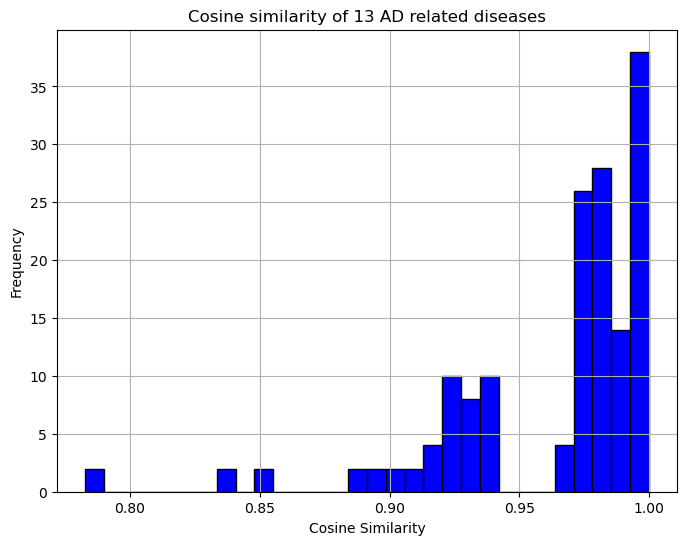

In [30]:
visualize_cosine_similarity(ad_embedding_cosine_similarity, 'Cosine similarity of 13 AD related diseases')

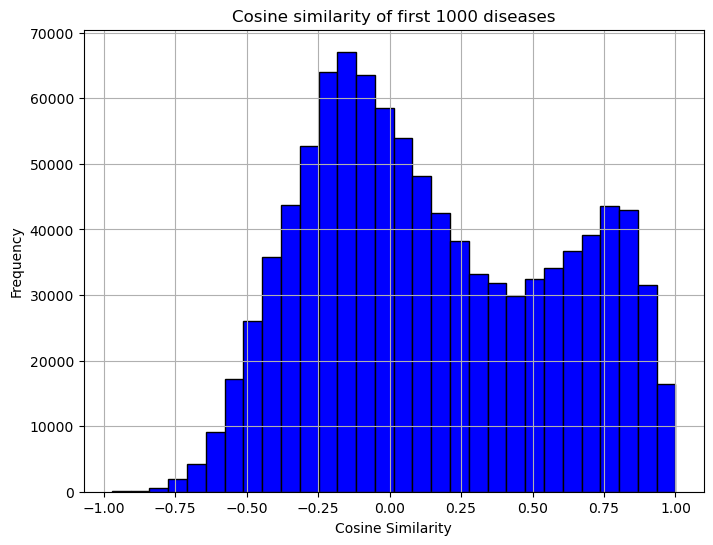

In [31]:
first_1000_embedding_cosine_similarity = cosine_similarity_between_all_rows(full_h_embed_hms[0:1000,:])
visualize_cosine_similarity(first_1000_embedding_cosine_similarity, 'Cosine similarity of first 1000 diseases')

thus the new_node_map_df should indeed be row names of embedding

## (3.2) save all phecode embeddings

In [32]:
full_h_embed_hms_phecode = full_h_embed_hms[new_node_map_df['ntype'].str.contains('PHECODE')]
full_h_embed_hms_phecode = pd.DataFrame(full_h_embed_hms_phecode.detach().numpy())
full_h_embed_hms_phecode = full_h_embed_hms_phecode.reset_index()
full_h_embed_hms_phecode = full_h_embed_hms_phecode.iloc[:,1:]
print(full_h_embed_hms_phecode.shape)
full_h_embed_hms_phecode

(1761, 128)


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,-5.613912,-6.432773,0.050036,5.052981,9.889101,2.258281,-0.883907,6.551761,3.881059,3.788872,...,-0.565339,1.791656,4.733319,-2.584308,0.515505,-3.772159,-10.875219,9.616881,2.038275,-2.803721
1,-9.838550,-5.677269,2.626187,4.892983,9.724641,2.085146,-2.364702,7.157976,6.470758,5.964633,...,1.734294,1.850960,3.896411,-3.282432,-1.373315,-4.093749,-10.554970,7.698358,4.022460,-2.114977
2,3.154929,8.078339,6.569836,3.956776,-1.140389,9.491807,-7.133209,9.456218,4.838665,1.096825,...,-9.876888,-3.284113,0.619864,-15.137610,11.950210,-8.751191,3.133143,10.073505,-13.360314,10.179700
3,-2.622596,-6.876009,-2.153514,5.126151,10.001644,1.613520,0.063038,4.636883,0.841122,1.277848,...,-1.977220,1.944672,5.136258,1.637232,0.160781,-2.207594,-11.402487,9.542363,0.272879,-4.537781
4,-5.519234,-7.728311,-0.591925,4.056235,9.760997,1.663896,0.125515,5.801831,4.281415,3.639843,...,0.479781,1.713608,5.517713,-1.976726,-0.171069,-3.685214,-10.815453,8.625010,2.546437,-2.871008
5,-7.262908,-5.511033,1.806878,5.850619,11.032728,1.712999,-1.137900,8.170679,4.019802,4.821373,...,-0.372716,3.372110,3.725044,-3.529612,-1.025851,-4.016889,-11.033668,8.709295,1.980632,-2.202516
6,-12.925422,2.439143,8.433492,5.991382,5.231721,-4.483116,-7.216887,5.245689,9.486841,-0.168312,...,1.994227,5.667627,-6.838697,0.104312,-3.378052,-14.821639,0.828371,1.788711,4.510599,3.670794
7,-11.356719,3.511211,8.050848,5.639572,3.508838,-4.057577,-8.242427,3.973473,9.137786,-1.514461,...,1.248343,4.197363,-7.255546,1.389030,-2.145438,-15.008186,1.889967,1.902768,3.013541,3.930502
8,-11.483304,3.446025,8.054852,5.916492,3.696149,-4.199293,-8.500775,4.079286,8.929102,-1.632805,...,1.313156,4.332166,-7.428759,1.638581,-2.152079,-14.972263,1.603778,2.091962,3.299096,3.436886
9,-9.795483,-10.745877,1.026366,-1.301657,5.968569,4.240695,-0.638935,0.806464,9.234221,-0.529317,...,3.028868,3.094262,6.975585,0.897696,-3.775044,-5.711600,-3.843209,3.869483,3.742006,-2.468353


In [33]:
new_node_map_df_phecode = new_node_map_df[new_node_map_df['ntype'].str.contains('PHECODE')]
new_node_map_df_phecode = new_node_map_df_phecode.reset_index()
new_node_map_df_phecode = new_node_map_df_phecode.iloc[:,1:]

print(new_node_map_df_phecode.shape)
new_node_map_df_phecode

(1761, 4)


,ntype,node_name,node_id,global_graph_index
0,PHECODE,Intestinal infection,8.0,24217
1,PHECODE,Bacterial enteritis,8.5,24218
2,PHECODE,Intestinal e.coli,8.51,24219
3,PHECODE,Intestinal infection due to C. difficile,8.52,24220
4,PHECODE,Viral Enteritis,8.6,24221
5,PHECODE,Intestinal infection due to protozoa,8.7,24222
6,PHECODE,Tuberculosis,10.0,24223
7,PHECODE,Diseases due to other mycobacteria,31.0,24224
8,PHECODE,Leprosy,31.1,24225
9,PHECODE,Septicemia,38.0,24226


In [34]:
full_h_embed_hms_phecode_df = pd.concat([full_h_embed_hms_phecode, new_node_map_df_phecode], axis = 1)

print(full_h_embed_hms_phecode_df.shape)
full_h_embed_hms_phecode_df.head()

(1761, 132)


,0,1,2,3,4,5,6,7,8,9,...,122,123,124,125,126,127,ntype,node_name,node_id,global_graph_index
0,-5.613912,-6.432773,0.050036,5.052981,9.889101,2.258281,-0.883907,6.551761,3.881059,3.788872,...,0.515505,-3.772159,-10.875219,9.616881,2.038275,-2.803721,PHECODE,Intestinal infection,8.0,24217
1,-9.838550,-5.677269,2.626187,4.892983,9.724641,2.085146,-2.364702,7.157976,6.470758,5.964633,...,-1.373315,-4.093749,-10.554970,7.698358,4.022460,-2.114977,PHECODE,Bacterial enteritis,8.5,24218
2,3.154929,8.078339,6.569836,3.956776,-1.140389,9.491807,-7.133209,9.456218,4.838665,1.096825,...,11.950210,-8.751191,3.133143,10.073505,-13.360314,10.179700,PHECODE,Intestinal e.coli,8.51,24219
3,-2.622596,-6.876009,-2.153514,5.126151,10.001644,1.613520,0.063038,4.636883,0.841122,1.277848,...,0.160781,-2.207594,-11.402487,9.542363,0.272879,-4.537781,PHECODE,Intestinal infection due to C. difficile,8.52,24220
4,-5.519234,-7.728311,-0.591925,4.056235,9.760997,1.663896,0.125515,5.801831,4.281415,3.639843,...,-0.171069,-3.685214,-10.815453,8.625010,2.546437,-2.871008,PHECODE,Viral Enteritis,8.6,24221


In [35]:
full_h_embed_hms_phecode_df.columns

Index([                   0,                    1,                    2,
                          3,                    4,                    5,
                          6,                    7,                    8,
                          9,
       ...
                        122,                  123,                  124,
                        125,                  126,                  127,
                    'ntype',          'node_name',            'node_id',
       'global_graph_index'],
      dtype='object', length=132)

In [36]:
full_h_embed_hms_phecode_df[['node_name', 'node_id']]

,node_name,node_id
0,Intestinal infection,8.0
1,Bacterial enteritis,8.5
2,Intestinal e.coli,8.51
3,Intestinal infection due to C. difficile,8.52
4,Viral Enteritis,8.6
5,Intestinal infection due to protozoa,8.7
6,Tuberculosis,10.0
7,Diseases due to other mycobacteria,31.0
8,Leprosy,31.1
9,Septicemia,38.0


In [37]:
type(full_h_embed_hms_phecode_df['node_id'][0])

str

In [38]:
pwd

'/scratch/gilbreth/yang1641/exome/data/disease_embedding/unified_clinical_vocabulary_embeddings'

In [95]:
full_h_embed_hms_phecode_df.to_csv(
    'full_h_embed_hms_phecode_df.tsv', index = False, sep = '\t'
)

## (3.3) load TTD x phecode drug target analysis to align with clinical embedding phecode

330 phecode diseases with (1) significant network expansion modules, and (2) have TTD drugs (drug status requirements)

->

325 diseases that (3) have clinical embedding

In [79]:
mkdir -p /scratch/gilbreth/yang1641/exome/data/network_expansion/enet_V3/ttd/olink_enet_V3_Jan28/

scp "/Users/apple/Dropbox (Penn)/exome/summary/contexual_gnn/network_expansion/enet_V3/ttd/olink_enet_V3_Jan28/all_phecode_more_info.tsv" yang1641@gilbreth.rcac.purdue.edu:/scratch/gilbreth/yang1641/exome/data/network_expansion/enet_V3/ttd/olink_enet_V3_Jan28/

SyntaxError: invalid syntax (1995660025.py, line 1)

In [39]:
ttd_phecode_summary = pd.read_csv('/scratch/gilbreth/yang1641/exome/data/network_expansion/enet_V3/ttd/olink_enet_V3_Jan28/all_phecode_more_info.tsv', 
                                 sep = '\t')
print(ttd_phecode_summary.shape)
ttd_phecode_summary.head()

(330, 39)


,phecode,phecode_idx,phecode_description,n_target,targets,n_target_seeds,n_target_nonseeds,n_approved_target_seeds,n_approved_target_nonseeds,n_seeds,...,prob_target,enrich_target_given_non_seed,prob_target_given_seed,enrich_target_given_seed,n_target_seed_or_nonseed,prob_target_given_seed_or_nonseed,enrich_target_given_seed_or_nonseed,n_seeds_ne_input,seeds_ne_input,Category
0,8.0,1,Intestinal infection,5,"ANO1,CFTR,CHRM5,EGFR,ICAM1",0,0,0,0,9,...,0.000214,0.000000,0.000000,0.000000,0,0.000000,0.000000,97,"CD302,EDA2R,LCN15,ELN,FAP,ITGA11,ITGAV,SFTPA2,TGFBI,TNR,VSIG2,ANGPT2,AREG,BLNK,CLEC3B,FGF23,GDF15,HJV,IGFBP7,LEFTY2,MEPE,PDCD1,SHH,SPINK5,WFIKKN1,ALPP,CLEC4A,FSTL1,GALNT10,HS6ST1,ICAM4,MSMB,PIGR,PLXNB2,REN,SMPD1,ST3GAL1,AMN,APOA4,CEACAM5,CPA4,FAM20A,ODAM,CCL11,CXCL9,IL10,IL15,IL18R1,IL22,TIGIT,GAL,GAST,INSL4,PPY,CELA3A,CPB1,GZMB,SPINK1,DTNB,ENTR1,NEFL,AIDA,MAMDC2,NELL1,TCP11,TPPP3,ACE2,AGR3,SPAG1,BST2,PTN,MPRIP,ENAH,HSPA2,PHLDB2,DPP10,TOP1,TPT1,CA14,MRPL46,FLT3LG,GSTT2B,ADA2,UNG,REG3A,FGFBP2,REG4,ZNF75D,FAM3D,ENPP6,LMNB2,SEL1L,SEPTIN8,HAVCR1,EFNA1,VIT,MIA",Infectious and parasitic
1,8.6,4,Viral Enteritis,2,"ANO1,CFTR",0,0,0,0,5,...,0.000086,0.000000,0.000000,0.000000,0,0.000000,0.000000,31,"ICAM3,LAG3,LILRB4,PDCD1,BCAN,ITGA11,ITGA2,GDF15,IGFBP7,PROCR,FOLR1,DPP4,TGOLN2,PPL,TNFRSF1B,HAVCR1,LEG1,LMOD1,EFNA1,PTN,POMC,PPP1R14D,TSHB,KLK13,RFC4,SART1,OMG,FGFBP2,EDA2R,IL36G,ENPP6",Infectious and parasitic
2,41.0,8,Bacterial infection NOS,9,"CALCRL,CRHR1,CRTC1,CSF2,CTSL,CXCL8,DHODH,PI4KB,TGFB2",1,1,0,0,29,...,0.000385,8.799623,0.034483,89.513410,2,0.006173,16.024005,157,"COL9A1,ITGA11,MSR1,WFIKKN1,BCAN,CCN5,CHAD,CTSL,ELN,FCGR3B,FN1,IGFBP6,IGFBP7,LACRT,LTBP2,MFAP5,NELL2,NRCAM,PROS1,PZP,TIMP2,TYRP1,CHRDL2,GDF15,LEFTY2,MEPE,SOST,ANGPT2,AREG,KIT,ITGA2,ITGAV,ITGB2,TNC,ADGRG2,CPE,CRH,EDN1,GAST,PPY,TSHB,CELSR2,CTHRC1,KIR3DL1,PDCD1,SPINK4,SUMF1,AGER,CILP,CNTN5,FETUB,MANSC1,REN,SIRPB1,VSTM2B,ADIPOQ,AMBP,AMN,C7,CEACAM5,CFHR5,CFP,ENDOU,IL1RN,ODAM,SCGB1A1,ST8SIA1,ADAM12,CPA2,GZMB,KLK4,ACTN2,LMOD2,MYBPC1,MYLPF,CHGB,DNER,NEFL,SPRR3,DENND2B,GSN,SORBS1,NOS3,SSH3,HSPB6,BRK1,PKD1,BCL2,IFIT1,MAPK13,PLIN1,PTEN,RBFOX3,TFF1,DTNB,NELL1,RNASE10,WFDC2,CST1,CLEC4D,LMNB1,TCTN3,LRRC25,ESR1,INSL3,PLB1,DPP4,EGFR,RET,EPB41L5,RAB39B,PSAP,AIF1L,CELA2A,KLK12,CD3E,CD80,CXCL13,GHR,IDO1,IL12RB1,IL15,IL18R1,IL19,IL1RL1,IL6,ITGAM,CNDP1,LYPLA2,PRDX2,ART3,ASS1,ENO3,ENPP5,GART,PEPD,SIRT5,ADA2,NAPRT,ERCC1,LGALS4,ELAVL4,PPIE,NUP50,CA14,FGFBP1,HJV,GFRAL,CLEC3B,CPM,RBP7,REG3A,TFF2,OMP,UPK3BL1,HAVCR1,OBP2B",Infectious and parasitic
3,41.2,10,Streptococcus infection,9,"CALCRL,CRHR1,CRTC1,CSF2,CTSL,CXCL8,DHODH,PI4KB,TGFB2",1,0,0,0,9,...,0.000385,0.000000,0.111111,288.432099,1,0.005128,13.312251,97,"BCAN,C1GALT1C1,CLSTN3,ELN,LAMA1,NCAN,PROS1,SIAE,SPINK4,TGFBI,TNC,VCAN,ADAMTS13,C7,CPM,FCGR2B,IL10,KLRB1,SLAMF8,ANGPT2,ANGPTL1,CD34,DMP1,REN,KLK4,SERPINA7,UMOD,ISLR2,LRIG1,OMG,ANXA5,HSPA2,FABP4,TFF1,MYBPC1,LMOD1,MYLPF,ARNTL,GFAP,HSPB6,MYOM3,OMP,TSC1,ACTA2,ANK2,ENAH,GSN,UHRF2,CHEK2,BRD3,RBFOX3,CREBZF,RANGAP1,ART3,PEPD,CDA,COL9A1,MSR1,JCHAIN,GAST,CDH23,CEACAM5,CTSL,DLL1,HAVCR1,TFPI2,VGF,DSG4,SPRR3,SLITRK1,IL36A,NTF4,FABP6,DKKL1,PLXNB2,SEMA4C,TFRC,WFDC2,RAB37,OSBPL2,CCL21,IFNW1,IL13,IL15,IL3,FCRL6,VCAM1,CST1,LTBP2,NELL1,MSLNL,FAM3B,ADAM23,RNASET2,CNTN5,ANXA10,TFF2",Infectious and parasitic
4,53.0,12,Herpes zoster,2,"AGTR2,TK1",0,0,0,0,2,...,0.000086,0.000000,0.000000,0.000000,0,0.000000,0.000000,21,"FCGR2B,SLAMF7,HPGDS,DCTPP1,EFNA4,FLT3LG,CTSV,ODAM,SERPINA3,ASGR1,CD70,B2M,CSF1,TNFSF13B,GDF15,IGDCC4,PON3,CXCL9,SLIRP,CAMLG,CSTB",Infectious and parasitic


In [40]:
sum(ttd_phecode_summary['n_target'] >= 50)

35

In [41]:
type(ttd_phecode_summary['phecode'][0])

numpy.float64

In [42]:
# Create a set of available node_ids for fast lookup
clinical_embed_available_phecodes = set(full_h_embed_hms_phecode_df['node_id'].astype(float))

# Add a new column 'clinical_embed_avail' to indicate if 'phecode' is available
ttd_phecode_summary['clinical_embed_avail'] = ttd_phecode_summary['phecode'].astype(float).isin(clinical_embed_available_phecodes)

In [43]:
ttd_phecode_summary[['phecode', 'phecode_description']].loc[~ttd_phecode_summary['clinical_embed_avail']]

,phecode,phecode_description
67,270.0,Disorders of protein plasma/amino-acid transport and metabolism
71,274.0,Gout and other crystal arthropathies
111,318.0,Tobacco use disorder
274,687.4,Disturbance of skin sensation
318,850.0,Hemorrhage or hematoma complicating a procedure


In [44]:
ttd_phecode_clinical_embed_avail = ttd_phecode_summary.loc[ttd_phecode_summary['clinical_embed_avail']]
print(ttd_phecode_clinical_embed_avail.shape)
ttd_phecode_clinical_embed_avail.head()

(325, 40)


,phecode,phecode_idx,phecode_description,n_target,targets,n_target_seeds,n_target_nonseeds,n_approved_target_seeds,n_approved_target_nonseeds,n_seeds,...,enrich_target_given_non_seed,prob_target_given_seed,enrich_target_given_seed,n_target_seed_or_nonseed,prob_target_given_seed_or_nonseed,enrich_target_given_seed_or_nonseed,n_seeds_ne_input,seeds_ne_input,Category,clinical_embed_avail
0,8.0,1,Intestinal infection,5,"ANO1,CFTR,CHRM5,EGFR,ICAM1",0,0,0,0,9,...,0.000000,0.000000,0.000000,0,0.000000,0.000000,97,"CD302,EDA2R,LCN15,ELN,FAP,ITGA11,ITGAV,SFTPA2,TGFBI,TNR,VSIG2,ANGPT2,AREG,BLNK,CLEC3B,FGF23,GDF15,HJV,IGFBP7,LEFTY2,MEPE,PDCD1,SHH,SPINK5,WFIKKN1,ALPP,CLEC4A,FSTL1,GALNT10,HS6ST1,ICAM4,MSMB,PIGR,PLXNB2,REN,SMPD1,ST3GAL1,AMN,APOA4,CEACAM5,CPA4,FAM20A,ODAM,CCL11,CXCL9,IL10,IL15,IL18R1,IL22,TIGIT,GAL,GAST,INSL4,PPY,CELA3A,CPB1,GZMB,SPINK1,DTNB,ENTR1,NEFL,AIDA,MAMDC2,NELL1,TCP11,TPPP3,ACE2,AGR3,SPAG1,BST2,PTN,MPRIP,ENAH,HSPA2,PHLDB2,DPP10,TOP1,TPT1,CA14,MRPL46,FLT3LG,GSTT2B,ADA2,UNG,REG3A,FGFBP2,REG4,ZNF75D,FAM3D,ENPP6,LMNB2,SEL1L,SEPTIN8,HAVCR1,EFNA1,VIT,MIA",Infectious and parasitic,True
1,8.6,4,Viral Enteritis,2,"ANO1,CFTR",0,0,0,0,5,...,0.000000,0.000000,0.000000,0,0.000000,0.000000,31,"ICAM3,LAG3,LILRB4,PDCD1,BCAN,ITGA11,ITGA2,GDF15,IGFBP7,PROCR,FOLR1,DPP4,TGOLN2,PPL,TNFRSF1B,HAVCR1,LEG1,LMOD1,EFNA1,PTN,POMC,PPP1R14D,TSHB,KLK13,RFC4,SART1,OMG,FGFBP2,EDA2R,IL36G,ENPP6",Infectious and parasitic,True
2,41.0,8,Bacterial infection NOS,9,"CALCRL,CRHR1,CRTC1,CSF2,CTSL,CXCL8,DHODH,PI4KB,TGFB2",1,1,0,0,29,...,8.799623,0.034483,89.513410,2,0.006173,16.024005,157,"COL9A1,ITGA11,MSR1,WFIKKN1,BCAN,CCN5,CHAD,CTSL,ELN,FCGR3B,FN1,IGFBP6,IGFBP7,LACRT,LTBP2,MFAP5,NELL2,NRCAM,PROS1,PZP,TIMP2,TYRP1,CHRDL2,GDF15,LEFTY2,MEPE,SOST,ANGPT2,AREG,KIT,ITGA2,ITGAV,ITGB2,TNC,ADGRG2,CPE,CRH,EDN1,GAST,PPY,TSHB,CELSR2,CTHRC1,KIR3DL1,PDCD1,SPINK4,SUMF1,AGER,CILP,CNTN5,FETUB,MANSC1,REN,SIRPB1,VSTM2B,ADIPOQ,AMBP,AMN,C7,CEACAM5,CFHR5,CFP,ENDOU,IL1RN,ODAM,SCGB1A1,ST8SIA1,ADAM12,CPA2,GZMB,KLK4,ACTN2,LMOD2,MYBPC1,MYLPF,CHGB,DNER,NEFL,SPRR3,DENND2B,GSN,SORBS1,NOS3,SSH3,HSPB6,BRK1,PKD1,BCL2,IFIT1,MAPK13,PLIN1,PTEN,RBFOX3,TFF1,DTNB,NELL1,RNASE10,WFDC2,CST1,CLEC4D,LMNB1,TCTN3,LRRC25,ESR1,INSL3,PLB1,DPP4,EGFR,RET,EPB41L5,RAB39B,PSAP,AIF1L,CELA2A,KLK12,CD3E,CD80,CXCL13,GHR,IDO1,IL12RB1,IL15,IL18R1,IL19,IL1RL1,IL6,ITGAM,CNDP1,LYPLA2,PRDX2,ART3,ASS1,ENO3,ENPP5,GART,PEPD,SIRT5,ADA2,NAPRT,ERCC1,LGALS4,ELAVL4,PPIE,NUP50,CA14,FGFBP1,HJV,GFRAL,CLEC3B,CPM,RBP7,REG3A,TFF2,OMP,UPK3BL1,HAVCR1,OBP2B",Infectious and parasitic,True
3,41.2,10,Streptococcus infection,9,"CALCRL,CRHR1,CRTC1,CSF2,CTSL,CXCL8,DHODH,PI4KB,TGFB2",1,0,0,0,9,...,0.000000,0.111111,288.432099,1,0.005128,13.312251,97,"BCAN,C1GALT1C1,CLSTN3,ELN,LAMA1,NCAN,PROS1,SIAE,SPINK4,TGFBI,TNC,VCAN,ADAMTS13,C7,CPM,FCGR2B,IL10,KLRB1,SLAMF8,ANGPT2,ANGPTL1,CD34,DMP1,REN,KLK4,SERPINA7,UMOD,ISLR2,LRIG1,OMG,ANXA5,HSPA2,FABP4,TFF1,MYBPC1,LMOD1,MYLPF,ARNTL,GFAP,HSPB6,MYOM3,OMP,TSC1,ACTA2,ANK2,ENAH,GSN,UHRF2,CHEK2,BRD3,RBFOX3,CREBZF,RANGAP1,ART3,PEPD,CDA,COL9A1,MSR1,JCHAIN,GAST,CDH23,CEACAM5,CTSL,DLL1,HAVCR1,TFPI2,VGF,DSG4,SPRR3,SLITRK1,IL36A,NTF4,FABP6,DKKL1,PLXNB2,SEMA4C,TFRC,WFDC2,RAB37,OSBPL2,CCL21,IFNW1,IL13,IL15,IL3,FCRL6,VCAM1,CST1,LTBP2,NELL1,MSLNL,FAM3B,ADAM23,RNASET2,CNTN5,ANXA10,TFF2",Infectious and parasitic,True
4,53.0,12,Herpes zoster,2,"AGTR2,TK1",0,0,0,0,2,...,0.000000,0.000000,0.000000,0,0.000000,0.000000,21,"FCGR2B,SLAMF7,HPGDS,DCTPP1,EFNA4,FLT3LG,CTSV,ODAM,SERPINA3,ASGR1,CD70,B2M,CSF1,TNFSF13B,GDF15,IGDCC4,PON3,CXCL9,SLIRP,CAMLG,CSTB",Infectious and parasitic,True


In [45]:
tmp = full_h_embed_hms_phecode_df
tmp['phecode'] = tmp['node_id'].astype(float)

ttd_phecode_clinical_embed = pd.merge(
    ttd_phecode_clinical_embed_avail, tmp, on = ['phecode']
)
print(ttd_phecode_clinical_embed.shape)
print(ttd_phecode_clinical_embed.columns.values)

(325, 172)
['phecode' 'phecode_idx' 'phecode_description' 'n_target' 'targets'
 'n_target_seeds' 'n_target_nonseeds' 'n_approved_target_seeds'
 'n_approved_target_nonseeds' 'n_seeds' 'n_nonseeds' 'n_genes' 'n_modules'
 'n_drug_gene_pair' 'n_drugs' 'n_approved_drugs' 'target_seeds'
 'target_nonseeds' 'seeds' 'nonseeds' 'drugs' 'approved_drugs'
 'drugs_for_seeds' 'approved_drugs_for_seeds' 'drugs_for_nonseeds'
 'approved_drugs_for_nonseeds' 'n_pairs_nonseed_approved'
 'n_pairs_seed_approved' 'prob_target_given_non_seed' 'prob_target'
 'enrich_target_given_non_seed' 'prob_target_given_seed'
 'enrich_target_given_seed' 'n_target_seed_or_nonseed'
 'prob_target_given_seed_or_nonseed' 'enrich_target_given_seed_or_nonseed'
 'n_seeds_ne_input' 'seeds_ne_input' 'Category' 'clinical_embed_avail' 0 1
 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28
 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52
 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 7

In [46]:
ttd_phecode_clinical_embed.to_csv(
    'ttd_phecode_clinical_embed.tsv', index = False, sep = '\t'
)

## (3.4) compute cosine similarity between all phecode diseases

In [47]:
full_h_embed_hms_phecode_tensor = full_h_embed_hms[new_node_map_df['ntype'].str.contains('PHECODE')]
print(type(full_h_embed_hms_phecode_tensor))
print(full_h_embed_hms_phecode_tensor.shape)

<class 'torch.Tensor'>
torch.Size([1761, 128])


torch.Size([1761, 1761])


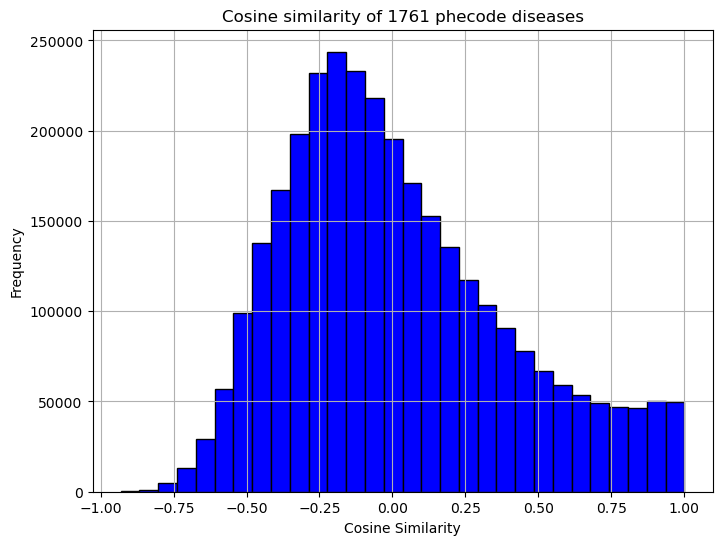

In [48]:
full_h_embed_hms_phecode_cosine_similarity = cosine_similarity_between_all_rows(full_h_embed_hms_phecode_tensor)
print(full_h_embed_hms_phecode_cosine_similarity.shape)
visualize_cosine_similarity(full_h_embed_hms_phecode_cosine_similarity, 'Cosine similarity of 1761 phecode diseases')

### check if the TTD-available phecode have different cosine similarity - look ok

In [49]:
ttd_phecode_clinical_embed.shape

(325, 172)

torch.Size([325, 325])


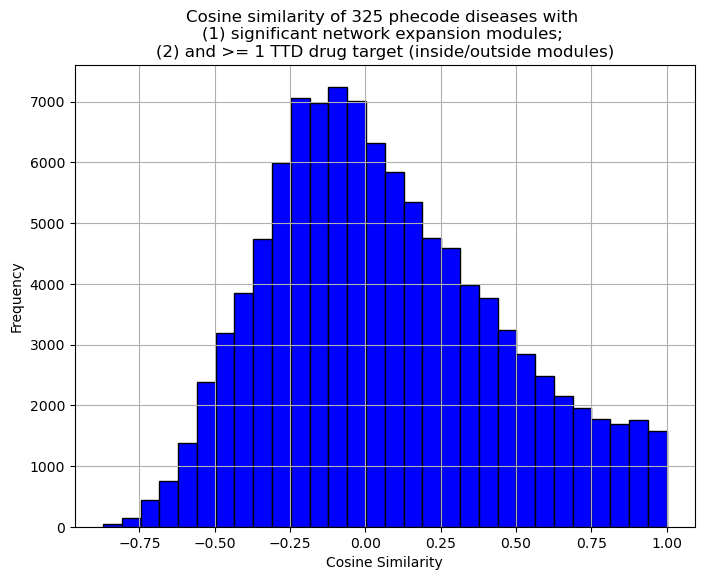

In [50]:
ttd_phecode_clinical_embed_cosine_similarity = cosine_similarity_between_all_rows(
    torch.tensor(ttd_phecode_clinical_embed[list(range(128))].values)
)
print(ttd_phecode_clinical_embed_cosine_similarity.shape)
visualize_cosine_similarity(
    ttd_phecode_clinical_embed_cosine_similarity, 
    'Cosine similarity of 325 phecode diseases with \n(1) significant network expansion modules; \n(2) and >= 1 TTD drug target (inside/outside modules)')

In [51]:
ttd_phecode_clinical_embed.head()

,phecode,phecode_idx,phecode_description,n_target,targets,n_target_seeds,n_target_nonseeds,n_approved_target_seeds,n_approved_target_nonseeds,n_seeds,...,122,123,124,125,126,127,ntype,node_name,node_id,global_graph_index
0,8.0,1,Intestinal infection,5,"ANO1,CFTR,CHRM5,EGFR,ICAM1",0,0,0,0,9,...,0.515505,-3.772159,-10.875219,9.616881,2.038275,-2.803721,PHECODE,Intestinal infection,8.0,24217
1,8.6,4,Viral Enteritis,2,"ANO1,CFTR",0,0,0,0,5,...,-0.171069,-3.685214,-10.815453,8.625010,2.546437,-2.871008,PHECODE,Viral Enteritis,8.6,24221
2,41.0,8,Bacterial infection NOS,9,"CALCRL,CRHR1,CRTC1,CSF2,CTSL,CXCL8,DHODH,PI4KB,TGFB2",1,1,0,0,29,...,-2.511606,-4.914264,-7.662252,4.905750,5.117131,-0.544004,PHECODE,Bacterial infection NOS,41.0,24230
3,41.2,10,Streptococcus infection,9,"CALCRL,CRHR1,CRTC1,CSF2,CTSL,CXCL8,DHODH,PI4KB,TGFB2",1,0,0,0,9,...,-4.052008,-5.389202,-2.841097,1.233458,6.001755,0.863939,PHECODE,Streptococcus infection,41.2,24234
4,53.0,12,Herpes zoster,2,"AGTR2,TK1",0,0,0,0,2,...,-3.180992,-3.664721,-4.567839,-3.355921,8.269244,2.602551,PHECODE,Herpes zoster,53.0,24239


In [52]:
print(ttd_phecode_clinical_embed.columns.values)

['phecode' 'phecode_idx' 'phecode_description' 'n_target' 'targets'
 'n_target_seeds' 'n_target_nonseeds' 'n_approved_target_seeds'
 'n_approved_target_nonseeds' 'n_seeds' 'n_nonseeds' 'n_genes' 'n_modules'
 'n_drug_gene_pair' 'n_drugs' 'n_approved_drugs' 'target_seeds'
 'target_nonseeds' 'seeds' 'nonseeds' 'drugs' 'approved_drugs'
 'drugs_for_seeds' 'approved_drugs_for_seeds' 'drugs_for_nonseeds'
 'approved_drugs_for_nonseeds' 'n_pairs_nonseed_approved'
 'n_pairs_seed_approved' 'prob_target_given_non_seed' 'prob_target'
 'enrich_target_given_non_seed' 'prob_target_given_seed'
 'enrich_target_given_seed' 'n_target_seed_or_nonseed'
 'prob_target_given_seed_or_nonseed' 'enrich_target_given_seed_or_nonseed'
 'n_seeds_ne_input' 'seeds_ne_input' 'Category' 'clinical_embed_avail' 0 1
 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28
 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52
 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 

In [53]:
ttd_phecode_50_targets_clinical_embed = ttd_phecode_clinical_embed.loc[
        (ttd_phecode_clinical_embed['n_target'] >= 50) & (ttd_phecode_clinical_embed['n_target_seed_or_nonseed'] > 0), 
        list(range(128))]

print(ttd_phecode_50_targets_clinical_embed.shape)

ttd_phecode_50_targets_clinical_embed.head()

(33, 128)


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
11,0.865335,-1.624810,-1.531132,8.407306,11.370545,-3.650595,0.339754,4.486088,-5.244853,1.901397,...,-4.291295,5.177221,1.869220,7.255885,-1.639246,0.946805,-12.121178,6.177011,-3.287297,-4.565413
12,-0.221411,2.653215,-0.273585,10.743002,11.215734,-3.534949,-1.965886,5.624162,-8.719849,-0.708765,...,-6.302063,5.567527,-4.174362,8.654675,-5.740412,1.796959,-11.777227,5.907737,-4.538461,-5.867557
15,-5.272686,-1.396398,-0.575043,2.584838,7.578587,-4.766933,3.940373,-2.383057,0.149234,2.086736,...,-1.221317,9.006707,2.753230,8.975786,-5.429244,-1.061673,-1.223133,-2.180101,0.472871,-0.328518
16,-6.023856,3.655597,5.098902,7.468716,8.706260,-6.617883,-3.804807,3.686900,-2.747145,1.939216,...,-0.373080,7.136521,-4.657701,10.396731,-9.855204,0.292760,-7.417765,-2.184052,-3.098838,-1.833275
17,-2.703381,6.038203,7.537846,7.287092,5.371607,-3.115627,-7.522860,7.252131,-4.721424,-1.528618,...,-1.431592,3.877225,-8.477526,5.908018,-10.433809,1.356693,-6.851294,-1.663733,-7.105818,-1.597811


torch.Size([33, 33])


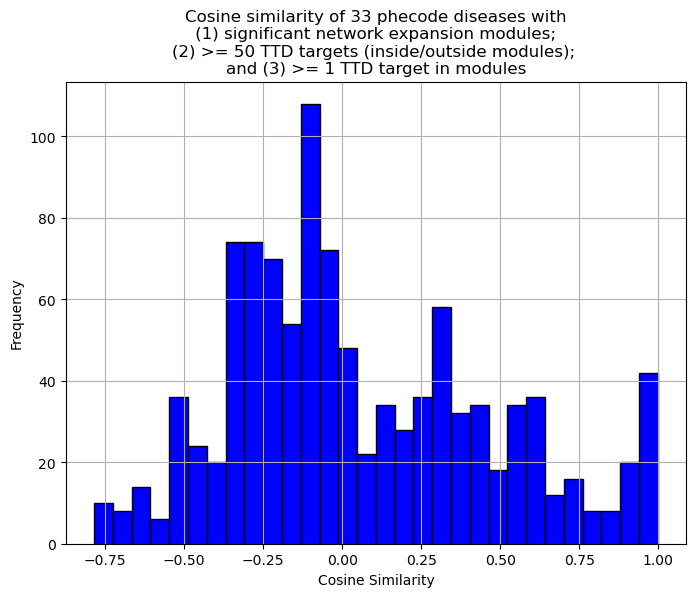

In [54]:
ttd_phecode_50_targets_clinical_embed_cosine_similarity = cosine_similarity_between_all_rows(
    torch.tensor(ttd_phecode_50_targets_clinical_embed.values)
)
print(ttd_phecode_50_targets_clinical_embed_cosine_similarity.shape)
visualize_cosine_similarity(
    ttd_phecode_50_targets_clinical_embed_cosine_similarity, 
    'Cosine similarity of 33 phecode diseases with\n (1) significant network expansion modules; \n(2) >= 50 TTD targets (inside/outside modules); \nand (3) >= 1 TTD target in modules')

### check which disease pair has $\approx$ 1 cosine similarity

290.0 and 290.1

attach phecode as rowname and colname

In [55]:
ttd_phecode_50_targets_clinical_embed_cosine_similarity_df = pd.DataFrame(
    ttd_phecode_50_targets_clinical_embed_cosine_similarity, 
    index = ttd_phecode_clinical_embed['phecode'].loc[
        (ttd_phecode_clinical_embed['n_target'] >= 50) & (ttd_phecode_clinical_embed['n_target_seed_or_nonseed'] > 0)
    ], 
    columns = ttd_phecode_clinical_embed['phecode'].loc[
        (ttd_phecode_clinical_embed['n_target'] >= 50) & (ttd_phecode_clinical_embed['n_target_seed_or_nonseed'] > 0)
    ]
)

ttd_phecode_50_targets_clinical_embed_cosine_similarity_df.head()

phecode,151.00,153.00,165.00,165.10,172.00,184.00,185.00,189.00,200.00,202.00,...,495.00,496.00,496.20,496.21,555.00,695.00,696.00,696.40,714.00,714.10
phecode,,,,,,,,,,,,,,,,,,,,,
151.0,1.000000,0.897100,0.349815,0.540173,0.331921,-0.083897,0.414617,0.005483,0.576126,0.601305,...,0.270604,0.229849,0.232951,-0.218016,0.279496,0.155177,-0.270386,0.095527,-0.145382,0.054870
153.0,0.897100,1.000000,0.197280,0.624040,0.626652,0.193883,0.655025,0.291998,0.483787,0.614732,...,0.034562,-0.009318,-0.010338,-0.195083,0.346789,0.116396,-0.123926,0.072618,-0.073635,0.052387
165.0,0.349815,0.197280,1.000000,0.658887,-0.046732,-0.371708,-0.036773,-0.256801,0.614857,0.554969,...,0.752561,0.800202,0.708395,0.036633,-0.422645,0.121547,-0.449080,0.028579,-0.286494,0.135652
165.1,0.540173,0.624040,0.658887,1.000000,0.687124,-0.114644,0.314391,-0.039939,0.672631,0.822230,...,0.534559,0.488580,0.448906,-0.093332,-0.234680,0.469180,-0.224223,0.411011,-0.063329,0.309944
172.0,0.331921,0.626652,-0.046732,0.687124,1.000000,0.384393,0.465932,0.353270,0.334399,0.587148,...,-0.008727,-0.112405,-0.104639,0.017127,0.194060,0.446150,0.278316,0.421099,0.047066,0.152914


In [56]:
# Find the row and column index of the maximum value
ttd_phecode_50_targets_clinical_embed_cosine_similarity_df_copy = ttd_phecode_50_targets_clinical_embed_cosine_similarity_df.copy()
np.fill_diagonal(ttd_phecode_50_targets_clinical_embed_cosine_similarity_df_copy.values, 0)

max_index = ttd_phecode_50_targets_clinical_embed_cosine_similarity_df_copy.values.argmax()
row_index, col_index = np.unravel_index(max_index, ttd_phecode_50_targets_clinical_embed_cosine_similarity_df_copy.shape)

# Get the row and column names
row_name = ttd_phecode_50_targets_clinical_embed_cosine_similarity_df_copy.index[row_index]
col_name = ttd_phecode_50_targets_clinical_embed_cosine_similarity_df_copy.columns[col_index]

print(row_name, col_name)
print(np.max(ttd_phecode_50_targets_clinical_embed_cosine_similarity_df_copy.values))
print(ttd_phecode_50_targets_clinical_embed_cosine_similarity_df.loc[row_name, col_name])

290.0 290.1
0.9986599
0.9986599


## (3.4) save the cosine similarity for all 1761 phecodes

In [57]:
full_h_embed_hms_phecode_cosine_similarity_df = pd.DataFrame(
    full_h_embed_hms_phecode_cosine_similarity, 
    index = full_h_embed_hms_phecode_df['node_id'].astype(str), 
    columns = full_h_embed_hms_phecode_df['node_id'].astype(str)
)

In [58]:
full_h_embed_hms_phecode_cosine_similarity.shape

torch.Size([1761, 1761])

In [59]:
# quick sanity check

print(full_h_embed_hms_phecode_cosine_similarity_df.loc['290.2', '290.2'])

print(full_h_embed_hms_phecode_cosine_similarity_df.loc['290.11', '290.2'])

1.0000001
0.95930284


In [246]:
full_h_embed_hms_phecode_cosine_similarity_df.to_csv(
    'full_h_embed_hms_phecode_cosine_similarity_df.csv', 
    sep = ',', index = True
)

## (3.5) define disease-disease edges according to ...?

### (now) candidate 1: disease-disease embedding cosine similarity above 0.4

### candidate 2: primeKG

https://www.nature.com/articles/s41597-023-01960-3

### check cell-cell interaction distribution in context ai

In [60]:
os.chdir('/scratch/gilbreth/yang1641/exome/data/PINNACLE/networks')
os.listdir()

['ppi_edgelists',
 'mg_edgelist.txt',
 'global_ppi_edgelist.txt',
 'full_h_embed_hms_phecode_cosine_similarity_df.csv',
 '.DS_Store']

In [61]:
mg_edgelist = pd.read_csv('mg_edgelist.txt', sep = '\t', header = None)
print(mg_edgelist.shape)
mg_edgelist.head()

(4018, 2)


,0,1
0,acinar cell of salivary gland,sperm
1,acinar cell of salivary gland,stromal cell
2,acinar cell of salivary gland,t follicular helper cell
3,acinar cell of salivary gland,tendon cell
4,acinar cell of salivary gland,tongue muscle cell


tissue terms start with BTO: 

https://github.com/mims-harvard/PINNACLE/blob/e3d2fced3bb812141e76a947351e25fbafb7ce6b/data_config.py#L24

In [62]:
mg_edgelist_cell_subset = mg_edgelist.loc[
    ~mg_edgelist[0].str.contains('BTO:'), ~mg_edgelist[1].str.contains('BTO:')
]
print(mg_edgelist_cell_subset.shape)
mg_edgelist_cell_subset.head()

(3939, 2)


,0,1
0,acinar cell of salivary gland,sperm
1,acinar cell of salivary gland,stromal cell
2,acinar cell of salivary gland,t follicular helper cell
3,acinar cell of salivary gland,tendon cell
4,acinar cell of salivary gland,tongue muscle cell


In [63]:
mg_edgelist_cell_subset.shape[0] / 154

25.57792207792208

#### each cell is connected with 16% of other cells

In [64]:
(mg_edgelist_cell_subset.shape[0] / 154) / 154

0.16609040310339013

### what cutoff of disease embedding cosine similarity would give us ~25 edges per disease?

### (already remove the diseases that have no drug targets in significant modules above)

In [65]:
def n_edges_at_cosine_similarity_cutoff(x, cutoff):
    # x is a n-by-n tensor
    x = x.copy()
    x = x[~torch.eye(x.shape[0], dtype=bool)]
    n_edges = sum(x >= cutoff) / 2
    n_diseases = x.shape[0]
    return n_edges/n_diseases

In [66]:
print(ttd_phecode_50_targets_clinical_embed_cosine_similarity_df.shape)

ttd_phecode_50_targets_clinical_embed_cosine_similarity_df

(33, 33)


phecode,151.00,153.00,165.00,165.10,172.00,184.00,185.00,189.00,200.00,202.00,...,495.00,496.00,496.20,496.21,555.00,695.00,696.00,696.40,714.00,714.10
phecode,,,,,,,,,,,,,,,,,,,,,
151.00,1.000000,0.897100,0.349815,0.540173,0.331921,-0.083897,0.414617,0.005483,0.576126,0.601305,...,0.270604,0.229849,0.232951,-0.218016,0.279496,0.155177,-0.270386,0.095527,-0.145382,0.054870
153.00,0.897100,1.000000,0.197280,0.624040,0.626652,0.193883,0.655025,0.291998,0.483787,0.614732,...,0.034562,-0.009318,-0.010338,-0.195083,0.346789,0.116396,-0.123926,0.072618,-0.073635,0.052387
165.00,0.349815,0.197280,1.000000,0.658887,-0.046732,-0.371708,-0.036773,-0.256801,0.614857,0.554969,...,0.752561,0.800202,0.708395,0.036633,-0.422645,0.121547,-0.449080,0.028579,-0.286494,0.135652
165.10,0.540173,0.624040,0.658887,1.000000,0.687124,-0.114644,0.314391,-0.039939,0.672631,0.822230,...,0.534559,0.488580,0.448906,-0.093332,-0.234680,0.469180,-0.224223,0.411011,-0.063329,0.309944
172.00,0.331921,0.626652,-0.046732,0.687124,1.000000,0.384393,0.465932,0.353270,0.334399,0.587148,...,-0.008727,-0.112405,-0.104639,0.017127,0.194060,0.446150,0.278316,0.421099,0.047066,0.152914
184.00,-0.083897,0.193883,-0.371708,-0.114644,0.384393,1.000000,0.266170,0.883515,-0.165336,0.011631,...,-0.424602,-0.430892,-0.474734,0.655339,0.753502,-0.341474,0.790733,-0.387475,-0.247022,-0.454841
185.00,0.414617,0.655025,-0.036773,0.314391,0.465932,0.266170,1.000000,0.487114,-0.084761,0.045210,...,-0.102315,-0.082196,-0.014453,-0.275431,0.108759,0.136510,-0.206219,0.032815,0.103118,-0.014877
189.00,0.005483,0.291998,-0.256801,-0.039939,0.353270,0.883515,0.487114,1.000000,-0.291166,-0.104606,...,-0.349281,-0.327383,-0.348124,0.592501,0.708606,-0.290118,0.638498,-0.389619,-0.180605,-0.384280
200.00,0.576126,0.483787,0.614857,0.672631,0.334399,-0.165336,-0.084761,-0.291166,1.000000,0.940786,...,0.409353,0.352301,0.303022,-0.109873,-0.113997,0.259703,-0.170443,0.286450,-0.093605,0.319585


### choose cosine similarity 0.4 as cutoff (0.1628, similar to 0.16609 above)

In [67]:
ttd_phecode_50_targets_clinical_embed_cosine_similarity_df.shape

(33, 33)

In [68]:
n_edges_at_cosine_similarity_cutoff_lst = []

for cutoff in np.linspace(0.1, 0.9, 17):
    tmp = n_edges_at_cosine_similarity_cutoff(
        ttd_phecode_50_targets_clinical_embed_cosine_similarity_df.values, 
        cutoff
    )
    n_edges_at_cosine_similarity_cutoff_lst.append(tmp)
    
print(n_edges_at_cosine_similarity_cutoff_lst)

[0.19886363636363635, 0.1893939393939394, 0.17140151515151514, 0.16287878787878787, 0.14109848484848486, 0.11837121212121213, 0.10984848484848485, 0.09564393939393939, 0.08522727272727272, 0.07859848484848485, 0.058712121212121215, 0.050189393939393936, 0.04450757575757576, 0.04071969696969697, 0.03598484848484849, 0.03125, 0.027462121212121212]


### generate disease-disease edge list

In [69]:
def col_row_value_above_cosine_similarity_cutoff(x, cutoff):
    # exclude diagnoal
    x = x.copy()
    np.fill_diagonal(x.values, 0)
    
    # x is an n-by-n np.array
    x.index.name = 'Row'
    x.columns.name = 'Column'

    # Extract values greater than 0.4 and avoid column name conflict
    result = (
        x.stack()
        .reset_index()  # Converts MultiIndex to columns
        .rename(columns={0: 'Value'})  # Avoids default naming conflict
    )

    # Filter only values greater than 0.4
    result = result[result['Value'] >= cutoff]
    
    result.columns = ['phecode_1', 'phecode_2', 'cosine_similarity']
    
    result = result[result['phecode_1'] < result['phecode_2']]
    
    return result

In [70]:
disease_disease_network = col_row_value_above_cosine_similarity_cutoff(
    ttd_phecode_50_targets_clinical_embed_cosine_similarity_df, 0.4)

print(disease_disease_network.shape)

print(disease_disease_network.describe())

disease_disease_network

(116, 3)
        phecode_1   phecode_2  cosine_similarity
count  116.000000  116.000000         116.000000
mean   252.897672  351.074828           0.682413
std    143.476546  191.423707           0.198641
min    151.000000  153.000000           0.402051
25%    165.100000  204.000000           0.533031
50%    200.000000  278.100000           0.614794
75%    278.000000  496.050000           0.898923
max    714.000000  714.100000           0.998660


,phecode_1,phecode_2,cosine_similarity
1,151.00,153.00,0.897100
3,151.00,165.10,0.540173
6,151.00,185.00,0.414617
8,151.00,200.00,0.576126
9,151.00,202.00,0.601305
10,151.00,202.20,0.587909
11,151.00,204.00,0.580311
12,151.00,204.10,0.594900
13,151.00,204.40,0.558973
36,153.00,165.10,0.624040


All 33 diseases are kept - all of them have edge with some other disease at cosine similarity >= 0.4

In [71]:
unique_disease_cosine_similarity_04 = np.unique(np.concatenate((disease_disease_network['phecode_1'].values, disease_disease_network['phecode_2'].values)))

print(len(unique_disease_cosine_similarity_04))

print(unique_disease_cosine_similarity_04)

33
[151.   153.   165.   165.1  172.   184.   185.   189.   200.   202.
 202.2  204.   204.1  204.4  250.   250.2  278.   278.1  290.   290.1
 290.11 335.   362.   495.   496.   496.2  496.21 555.   695.   696.
 696.4  714.   714.1 ]


In [72]:
ttd_phecode_clinical_embed['phecode_description'].loc[
    ttd_phecode_clinical_embed['phecode'].astype(float).isin(unique_disease_cosine_similarity_04)
]

11                                                    Cancer of stomach
12                                                    Colorectal cancer
15                                 Cancer within the respiratory system
16                                             Cancer of bronchus; lung
17                                                          Skin cancer
21                                Cancer of other female genital organs
22                                                   Cancer of prostate
24                  Cancer of urinary organs (incl. kidney and bladder)
36                                           Myeloproliferative disease
37                         Cancer of other lymphoid, histiocytic tissue
38                                                Non-Hodgkins lymphoma
41                                                             Leukemia
42                                                    Lymphoid leukemia
45                                                     Multiple 

### compare with context ai drug number

In [ ]:
'/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/positive_proteins_EFO_0003767.json'

In [73]:
import json

with open('/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/positive_proteins_EFO_0003767.json') as f:
    context_ai_IBD_drug_target_orig = json.load(f)
    print((context_ai_IBD_drug_target_orig.keys()))

dict_keys(['EFO_0003767'])


In [74]:
context_ai_IBD_drug_target = context_ai_IBD_drug_target_orig['EFO_0003767']

context_ai_IBD_drug_target_unique = set()

for k in context_ai_IBD_drug_target.keys():
    context_ai_IBD_drug_target_unique = context_ai_IBD_drug_target_unique.union(set(context_ai_IBD_drug_target[k]))
    
print(len(context_ai_IBD_drug_target_unique))

114


In [75]:
context_ai_IBD_drug_target_by_cell = []

for k in context_ai_IBD_drug_target.keys():
    context_ai_IBD_drug_target_by_cell.append(len(context_ai_IBD_drug_target[k]))
    
pd.Series(context_ai_IBD_drug_target_by_cell).describe()

count    157.000000
mean      17.375796
std       10.310198
min        6.000000
25%       11.000000
50%       15.000000
75%       22.000000
max      114.000000
dtype: float64

### compare with TTD drug target number for each of the 33 diseases - similar scale

also see ~/Penn Dropbox/Xiaochen Yang/exome/code/contextual_gnn/network_expansion/summary/olink/ttd_analysis_for_each_disease_Jan28_2025.R

In [76]:
ttd_phecode_clinical_embed['n_target_seed_or_nonseed'].loc[
    ttd_phecode_clinical_embed['phecode'].astype(float).isin(unique_disease_cosine_similarity_04)
].describe()

count    33.000000
mean     16.212121
std      13.905389
min       1.000000
25%       5.000000
50%      11.000000
75%      26.000000
max      60.000000
Name: n_target_seed_or_nonseed, dtype: float64

### save disease-disease network (node name = phecode)

In [77]:
mkdir -p /scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks

In [78]:
disease_disease_network.head()

,phecode_1,phecode_2,cosine_similarity
1,151.0,153.0,0.897100
3,151.0,165.1,0.540173
6,151.0,185.0,0.414617
8,151.0,200.0,0.576126
9,151.0,202.0,0.601305


In [124]:
disease_disease_network[['phecode_1', 'phecode_2']].to_csv(
    '/scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks/phecode_phecode_edge_list_33.txt', 
    index = False, sep = '\t', header = False, quoting=csv.QUOTE_NONE
)

### save disease-disease network (node name = phecode description)

In [80]:
disease_disease_network_copy = disease_disease_network.copy()
disease_disease_network_copy = pd.merge(
    disease_disease_network_copy, 
    ttd_phecode_clinical_embed[['phecode', 'phecode_description']], 
    left_on = 'phecode_1', right_on = 'phecode'
)
disease_disease_network_copy = disease_disease_network_copy.drop(columns=['phecode'])

disease_disease_network_copy = pd.merge(
    disease_disease_network_copy, 
    ttd_phecode_clinical_embed[['phecode', 'phecode_description']], 
    left_on = 'phecode_2', right_on = 'phecode', 
    suffixes = ('_1', '_2')
)
disease_disease_network_copy = disease_disease_network_copy.drop(columns=['phecode'])

disease_disease_network_copy

,phecode_1,phecode_2,cosine_similarity,phecode_description_1,phecode_description_2
0,151.00,153.00,0.897100,Cancer of stomach,Colorectal cancer
1,151.00,165.10,0.540173,Cancer of stomach,Cancer of bronchus; lung
2,153.00,165.10,0.624040,Colorectal cancer,Cancer of bronchus; lung
3,165.00,165.10,0.658887,Cancer within the respiratory system,Cancer of bronchus; lung
4,151.00,185.00,0.414617,Cancer of stomach,Cancer of prostate
5,153.00,185.00,0.655025,Colorectal cancer,Cancer of prostate
6,172.00,185.00,0.465932,Skin cancer,Cancer of prostate
7,151.00,200.00,0.576126,Cancer of stomach,Myeloproliferative disease
8,153.00,200.00,0.483787,Colorectal cancer,Myeloproliferative disease
9,165.00,200.00,0.614857,Cancer within the respiratory system,Myeloproliferative disease


In [81]:
disease_disease_network_copy.to_csv(
    '/scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks/phecode_phecode_edge_list_33.csv', 
    index = False
)

In [73]:
import csv

In [123]:
disease_disease_network_copy[['phecode_description_1', 'phecode_description_2']].to_csv(
    '/scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks/phecode_description_phecode_description_edge_list_33.txt', 
    index = False, sep = '\t', header = False, quoting=csv.QUOTE_NONE
)

### check connectivity of disease-disease network - indeed have two connected components

In [128]:
G = nx.Graph()
# Add edges from the DataFrame
G.add_edges_from(disease_disease_network_copy[['phecode_description_1', 'phecode_description_2']].values)
n_connected_components = nx.number_connected_components(G)

print(n_connected_components)

2


In [130]:
list(nx.connected_components(G))

[{'Asthma',
  'Cancer of bronchus; lung',
  'Cancer of other female genital organs',
  'Cancer of other lymphoid, histiocytic tissue',
  'Cancer of prostate',
  'Cancer of stomach',
  'Cancer of urinary organs (incl. kidney and bladder)',
  'Cancer within the respiratory system',
  'Chronic airway obstruction',
  'Chronic bronchitis',
  'Colorectal cancer',
  'Erythematous conditions',
  'Inflammatory bowel disease and other gastroenteritis and colitis',
  'Leukemia',
  'Lymphoid leukemia',
  'Multiple myeloma',
  'Myeloproliferative disease',
  'Non-Hodgkins lymphoma',
  'Obstructive chronic bronchitis',
  'Psoriasis',
  'Psoriasis and related disorders',
  'Rheumatoid arthritis',
  'Rheumatoid arthritis and other inflammatory polyarthropathies',
  'Skin cancer'},
 {"Alzheimer's disease",
  'Delirium dementia and amnestic and other cognitive disorders',
  'Dementias',
  'Diabetes mellitus',
  'Multiple sclerosis',
  'Obesity',
  'Other retinal disorders',
  'Overweight, obesity and ot

In [137]:
len(list(nx.connected_components(G))[0])

24

In [134]:
list(nx.connected_components(G))[0]

{'Asthma',
 'Cancer of bronchus; lung',
 'Cancer of other female genital organs',
 'Cancer of other lymphoid, histiocytic tissue',
 'Cancer of prostate',
 'Cancer of stomach',
 'Cancer of urinary organs (incl. kidney and bladder)',
 'Cancer within the respiratory system',
 'Chronic airway obstruction',
 'Chronic bronchitis',
 'Colorectal cancer',
 'Erythematous conditions',
 'Inflammatory bowel disease and other gastroenteritis and colitis',
 'Leukemia',
 'Lymphoid leukemia',
 'Multiple myeloma',
 'Myeloproliferative disease',
 'Non-Hodgkins lymphoma',
 'Obstructive chronic bronchitis',
 'Psoriasis',
 'Psoriasis and related disorders',
 'Rheumatoid arthritis',
 'Rheumatoid arthritis and other inflammatory polyarthropathies',
 'Skin cancer'}

## TODO: consider trying the larger connected component - need to create the disease-disease subnetwork and the disease specific PPIs in a separate folder

save the two connected components separately, so are their respective disease specific ppi

In [136]:
disease_disease_network_description_component_1 = disease_disease_network_copy.copy()
disease_disease_network_description_component_1 = disease_disease_network_description_component_1.loc[
    disease_disease_network_description_component_1['phecode_description_1'].isin(list(nx.connected_components(G))[0]) & 
    disease_disease_network_description_component_1['phecode_description_2'].isin(list(nx.connected_components(G))[0])
    
]
print(disease_disease_network_description_component_1.shape)
disease_disease_network_description_component_1

(90, 5)


,phecode_1,phecode_2,cosine_similarity,phecode_description_1,phecode_description_2
0,151.00,153.00,0.897100,Cancer of stomach,Colorectal cancer
1,151.00,165.10,0.540173,Cancer of stomach,Cancer of bronchus; lung
2,153.00,165.10,0.624040,Colorectal cancer,Cancer of bronchus; lung
3,165.00,165.10,0.658887,Cancer within the respiratory system,Cancer of bronchus; lung
4,151.00,185.00,0.414617,Cancer of stomach,Cancer of prostate
5,153.00,185.00,0.655025,Colorectal cancer,Cancer of prostate
6,172.00,185.00,0.465932,Skin cancer,Cancer of prostate
7,151.00,200.00,0.576126,Cancer of stomach,Myeloproliferative disease
8,153.00,200.00,0.483787,Colorectal cancer,Myeloproliferative disease
9,165.00,200.00,0.614857,Cancer within the respiratory system,Myeloproliferative disease


In [138]:
disease_disease_network_description_component_1[['phecode_description_1', 'phecode_description_2']].to_csv(
    '/scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks/phecode_description_phecode_description_edge_list_24.txt', 
    index = False, sep = '\t', header = False, quoting=csv.QUOTE_NONE
)

In [140]:
disease_disease_network_description_component_2 = disease_disease_network_copy.copy()
disease_disease_network_description_component_2 = disease_disease_network_description_component_2.loc[
    disease_disease_network_description_component_2['phecode_description_2'].isin(list(nx.connected_components(G))[1]) & 
    disease_disease_network_description_component_2['phecode_description_2'].isin(list(nx.connected_components(G))[1])
    
]
print(disease_disease_network_description_component_2.shape)
disease_disease_network_description_component_2

(26, 5)


,phecode_1,phecode_2,cosine_similarity,phecode_description_1,phecode_description_2
88,250.00,250.20,0.992979,Diabetes mellitus,Type 2 diabetes
89,250.00,278.00,0.921971,Diabetes mellitus,"Overweight, obesity and other hyperalimentation"
90,250.20,278.00,0.913040,Type 2 diabetes,"Overweight, obesity and other hyperalimentation"
91,250.00,278.10,0.875750,Diabetes mellitus,Obesity
92,250.20,278.10,0.904390,Type 2 diabetes,Obesity
93,278.00,278.10,0.823235,"Overweight, obesity and other hyperalimentation",Obesity
94,250.00,290.11,0.411443,Diabetes mellitus,Alzheimer's disease
95,250.20,290.11,0.466223,Type 2 diabetes,Alzheimer's disease
96,278.00,290.11,0.433601,"Overweight, obesity and other hyperalimentation",Alzheimer's disease
97,278.10,290.11,0.602253,Obesity,Alzheimer's disease


In [141]:
disease_disease_network_description_component_2[['phecode_description_1', 'phecode_description_2']].to_csv(
    '/scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks/phecode_description_phecode_description_edge_list_9.txt', 
    index = False, sep = '\t', header = False, quoting=csv.QUOTE_NONE
)

# (2) disease-specific PPI for the 33 diseases

## TODO: decide between
## (1) build separate PPI for each module (then combine by disease), or 
## build one PPI using all proteins from all modules associated with a disease? 

The latter would include additional edges between modules

current choice: (2)

In [ ]:
scp "/Users/apple/Dropbox (Penn)/exome/summary/contexual_gnn/network_expansion/enet_V3/all_phecode_clusters_significant_ks_testing_fdr.tsv" yang1641@gilbreth.rcac.purdue.edu:/scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks/

In [83]:
os.chdir('/scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks')

In [84]:
phecode_module = pd.read_csv('all_phecode_clusters_significant_ks_testing_fdr.tsv', sep = '\t')
print(phecode_module.shape)
phecode_module.head()

(2026, 29)


,clust,all.nodes,gwa.nodes,fisher,KS,KS_selected,fisher_selected,n_genes,genes,n_seeds,...,KS_fdr,KS_bonf,fisher_fdr,fisher_bonf,KS_fdr_selected,prop_seeds,olink_genes,n_olink_genes,prop_olink_genes,module_name
0,5,49,4,0.000344,2.211705e-08,True,True,49,"C1R,C1S,CELA3A,CLPS,CPA1,CPA2,CPA5,CPA6,CPB1,CPB2,CPXM1,CTSG,ELANE,F10,F12,F2,F9,GZMA,GZMB,GZMH,GZMK,HP,HPN,HPR,KLK10,KLK15,KLK2,KLK3,KLK5,KLK6,KLK7,KLKB1,LPA,MASP2,PLAT,PLAU,PNLIP,PROC,PRSS1,PRSS3,PRSS8,PRTN3,SPINK1,ST14,SYCN,TMPRSS13,TMPRSS5,TMPRSS6,TPSB2",4,...,4.340420e-07,0.000231,0.001578,1.0,True,0.081633,"C1R,C1S,CELA3A,CLPS,CPA1,CPA2,CPB1,CPB2,CPXM1,F10,F12,F2,F9,GZMA,GZMB,GZMH,KLK10,KLK15,KLK3,KLK6,KLK7,KLKB1,LPA,PLAT,PLAU,PNLIP,PROC,PRSS8,PRTN3,SPINK1,TMPRSS5",31,0.632653,8_5
1,6;4;1;3,323,3,0.190809,2.661531e-03,True,False,323,"ABCG2,ACE2,ACSL1,AGR2,AGR3,AGTRAP,AHNAK,AIP,ALDH1A1,ALDH3B1,ALDOA,AMBRA1,ANXA1,ANXA2,ANXA3,ANXA5,ANXA7,ARAF,ARHGDIA,ASXL1,ATG12,ATG5,ATG7,ATOH1,ATR,ATXN1,ATXN10,ATXN3,AURKA,B3GNT2,BACH1,BAG2,BAG3,BAG5,BAX,BCL2L1,BID,CACYBP,CALCOCO2,CALR,CAP1,CAPN1,CBR1,CCP110,CDC123,CDK1,CEP250,CEP290,CEP97,CHCHD3,CHMP3,CIP2A,CKAP2,CKAP5,CKB,CLCN2,CLEC16A,CLIP1,CNN3,COLGALT1,COPS3,COPS4,COPS6,CRYAB,CSE1L,CSN3,CSNK1A1,CUL4A,CUX1,CYCS,CYLD,CYP1A1,DCAF7,DCD,DDX58,DIP2A,DNAJA1,DNAJA2,DNAJB1,DNAJB4,DNAJC11,DNAJC7,DNM1L,DPP9,DYNC1I2,EGLN3,EZH2,FANCD2,FBXO32,FBXO7,FKBP4,FKBP5,FOLR1,GABARAPL1,GABRA1,GAPDH,GCN1L1,GDI2,GLB1,GLRX3,GNB2L1,GPC1,GPRASP2,GPS1,GSTM3,GSTP1,GYS1,HADHB,HAX1,HBA1,HDLBP,HERC2,HIF1AN,HMGB1,HNRNPH1,HSF1,HSP90AA1,HSP90AB1,HSP90AB4P,HSP90B1,HSPA1A,HSPA1B,HSPA1L,HSPA4,HSPA4L,HSPA6,HSPA8,HSPA9,HSPB1,HSPB8,HSPH1,HUWE1,IDE,IKBKE,ILK,INSIG1,IPO9,IQCB1,IRAK1,IRS4,JUN,KBTBD4,KIAA1524,KLHL22,KPNA1,LAMTOR5,LCOR,LDHA,LDHB,LGALS3BP,LMNA,MAD2L2,MAGED2,MAIP1,MAP1B,MAP1LC3A,MAP1LC3B,MAP2K7,MAP3K1,MAPK7,MDH1,MFN2,MIF,MIS18BP1,MKS1,MLST8,MME,MTNAP1,MTNR1B,MTPN,MYC,NBR1,NCAPH2,NDRG1,NEDD1,NEK4,NEK7,NEURL4,NHLRC2,NLRP3,NME2P1,NOS2,NPEPPS,NPHP4,NR3C1,NUDCD3,NUP62,OPA1,OPTN,P4HA2,PARK2,PB1,PCMT1,PDCD6,PDIA3,PFDN1,PGAM5,PIK3R4,PINK1,PIP,PLD2,PLOD1,PLOD3,PLS3,PML,POT1,PPIA,PPIB,PPID,PPP2R1A,PPP2R2A,PPP5C,PPP6C,PPP6R3,PPT1,PRDX1,PREP,PRKAB1,PRSS23,PTGES3,RANBP9,RB1CC1,RBM11,RCN1,RCN2,RHEB,RIN3,RIPK4,RNF123,RNF43,RNF8,RPGRIP1L,RPTOR,RUFY1,S100A6,SAMHD1,SEH1L,SERPINH1,SETX,SGTA,SIRT2,SLC25A1,SLC25A11,SLC25A13,SLC25A4,SLC25A6,SMG8,SOD1,SOX2,SPAG1,SPAG9,SPAST,SREBF1,SREBF2,ST13,STK4,STUB1,SUGT1,TACC3,TAGLN,TAGLN2,TBK1,TCEB1,TCEB2,TCOF1,TIMM50,TNFRSF1B,TNIP2,TNPO2,TOMM20,TOMM34,TP53,TRAF3,TRIM14,TRIM21,TRIM25,TRIM33,TRIM56,TRIM66,TRIM67,TSC22D1,TTI1,TTK,TUBA1A,TUBA1B,TUBA1C,TUBA4A,TUBA8,TUBB,TUBB1,TUBB2A,TUBB2B,TUBB3,TUBB4A,TUBB4B,TUBB6,TUBG1,TUBGCP3,TXN,TXNDC12,TXNIP,UBQLN2,UCHL1,UNC45A,UNK,USP15,USP19,USP4,USP7,UVRAG,VCP,VDAC1,VDAC2,VHL,VIM,WWOX,XPO5,XPOT,ZBTB33,ZKSCAN1,ZNF318,ZNF598,ZNHIT2",3,...,1.641486e-02,1.000000,0.222157,1.0,True,0.009288,"ACE2,ACSL1,AGR2,AGR3,AHNAK,ALDH1A1,ANXA1,ANXA2,ANXA3,ANXA5,ARAF,ATXN10,ATXN3,BACH1,BAG3,BAX,BCL2L1,BID,CACYBP,CALCOCO2,CDC123,CDK1,CEP290,CKB,DDX58,DNAJA1,DNAJA2,DNAJB1,FKBP4,FKBP5,FOLR1,GABARAPL1,GAPDH,GLB1,GPC1,GSTP1,GYS1,HSP90B1,HSPA1A,HSPB1,IRAK1,JUN,LAMTOR5,LGALS3BP,MAP1LC3A,MDH1,MIF,MME,MTPN,NDRG1,NEK7,NOS2,PDCD6,PDIA3,PPIB,PPT1,PRDX1,PRKAB1,RIPK4,RNF43,SERPINH1,SIRT2,SOD1,SOX2,SPAG1,ST13,STK4,SUGT1,TACC3,TCOF1,TNFRSF1B,TOMM20,TP53,TRAF3,TRIM21,TRIM25,TSC22D1,TUBB3,TXN,VIM",80,0.247678,8_6;4;1;3
2,9;3,161,2,0.190809,3.794964e-03,True,False,161,"AARS2,ABCF2-H2BK1,ABCF3,AFG3L2,AK1,AK2,AK3,AK4,AK9,APMAP,ARL3,ARL6IP1,ATP5F1A,ATP5F1B,ATP5F1C,ATP5MC1,ATP5MC2,ATP5MC3,ATP5PO,ATP6V0B,ATP6V0C,BCS1L,CD74,CDCA8,CLPP,CMPK1,CXORF66,DKC1,DROSHA,EEF2,EFL1,EIF1AX,EIF1AY,EIF5B,ELAC2,ENO4,ERAL1,FANCE,FASTKD3,FLT3LG,GFM1,GFM2,GSTT2B,GSTZ1,GTPBP10,GTPBP3,GTPBP6,GUF1,HMGN1,HMGN2,HMGN4,HSPBP1,IARS2,IFI35,IMP3,LONP1,MALSU1,METAP1,METAP2,METTL15,MRM1,MRM2,MRM3,MRNIP,MRPL1,MRPL12,MRPL13,MRPL16,MRPL17,MRPL19,MRPL2,MRPL20,MRPL21,MRPL22,MRPL24,MRPL27,MRPL3,MRPL32,MRPL33,MRPL36,MRPL39,MRPL4,MRPL44,MRPL58,MRPL9,MRPS10,MRPS11,MRPS12,MRPS14,MRPS15,MRPS16,MRP

155 modules for 33 phecode diseases

In [85]:
phecode_module_33 = phecode_module.loc[
    phecode_module['phecode'].isin(unique_disease_cosine_similarity_04)
]

print(phecode_module_33.shape)
print(phecode_module_33['phecode'].nunique())
phecode_module_33.head()

(155, 29)
33


,clust,all.nodes,gwa.nodes,fisher,KS,KS_selected,fisher_selected,n_genes,genes,n_seeds,...,KS_fdr,KS_bonf,fisher_fdr,fisher_bonf,KS_fdr_selected,prop_seeds,olink_genes,n_olink_genes,prop_olink_genes,module_name
50,2,55,3,0.003405,1.496203e-05,True,True,55,"APLP2,C1R,C1S,CPA1,CTSG,ELANE,F10,F11,F12,F2,F9,FCN1,GZMA,GZMB,GZMH,GZMK,HP,HPN,HPR,KLK10,KLK15,KLK2,KLK3,KLK5,KLK6,KLK7,KLKB1,LPA,MASP1,MASP2,MBL2,PLAT,PLAU,PLG,PROC,PRSS1,PRSS3,PRSS8,PRTN3,SERPINA10,SERPINA4,SERPINA5,SERPINC1,SERPIND1,SERPINF2,SERPING1,SPINK1,ST14,TFPI,THBD,TMPRSS11B,TMPRSS13,TMPRSS2,TMPRSS4,TMPRSS5",3,...,0.000166,0.156503,0.010128,1.000000,True,0.054545,"C1R,C1S,CPA1,F10,F11,F12,F2,F9,FCN1,GZMA,GZMB,GZMH,KLK10,KLK15,KLK3,KLK6,KLK7,KLKB1,LPA,MASP1,MBL2,PLAT,PLAU,PLG,PROC,PRSS8,PRTN3,SERPINA4,SERPINA5,SERPINC1,SERPIND1,SERPINF2,SERPING1,SPINK1,TFPI,THBD,TMPRSS11B,TMPRSS5",38,0.690909,151_2
51,3;1,126,3,0.011509,8.309180e-04,True,True,126,"ACAN,ACE,ACHE,AGRN,ALB,AMBN,AMELX,AMN,AMTN,ANTXR2,APOB,APOD,APOE,APP,ATP4B,BCHE,BPIFA2,C3,C4A,CASP1,CBLIF,CCN2,CCR1,CD14,CD36,CD55,CD59,CFH,CLU,CSHL1,CST3,CST4,CTSB,CTSC,CTSF,CTSK,CTSL,CTSS,CTSZ,CUBN,DSC2,EFEMP1,ELN,EMILIN1,F3,F5,F8,FAM20C,FBLN1,FBLN5,FBN2,FCRL4,FURIN,FZD4,GKN1,GKN2,GPC3,GPC4,GRP78,HMOX1,IGFBP3,IGHM,IGLL5,ITGA2B,ITGB3,KCNE2,KIAA0319,KNG1,LDLR,LDLRAP1,LGMN,LIPG,LOX,LRP1,LRP2,LRRC47,LTF,LYZ,MEP1B,MMP2,MMP9,MPO,NRSN1,ODAPH,P4HB,PASK,PCSK9,PIGR,PIGT,PLAUR,PLD3,PPIB,PPY,PROS1,PRPH2,PTGS2,PXDN,RETN,RHBDD1,SCARB1,SDC1,SDC2,SDC4,SLC18A3,SLC2A8,SORL1,SOST,SPINT2,SPP1,TCN1,TF,TFF2,TFPI2,TGFB1,THBS1,TIMP1,TIMP2,TIMP3,TRIM68,TRPC6,UPK1A,VCAN,VTN,VWF,WDR87,WNT3A",3,...,0.005913,1.000000,0.025925,1.000000,True,0.023810,"ACAN,ACE,ACHE,AGRN,AMBN,AMN,APOB,APOD,APOE,APP,BCHE,BPIFA2,C3,CASP1,CBLIF,CCN2,CD14,CD36,CD55,CD59,CFH,CLU,CST3,CTSB,CTSC,CTSF,CTSL,CTSS,CTSZ,DSC2,EFEMP1,ELN,F3,FBN2,FURIN,GKN1,HMOX1,IGFBP3,KIAA0319,LDLR,LDLRAP1,LGMN,LRP1,LRP2,MEP1B,MMP9,MPO,P4HB,PCSK9,PIGR,PLAUR,PPIB,PPY,PROS1,RETN,SCARB1,SDC1,SDC4,SOST,SPINT2,SPP1,TCN1,TF,TFF2,TFPI2,TGFB1,TIMP1,TIMP2,TIMP3,VCAN,VWF",71,0.563492,151_3;1
52,6;2;2;1,380,2,0.190220,1.106537e-06,True,False,380,"AAR2,AARSD1,ACACA,ACLY,AGR2,AHCYL1,AHSA1,AIFM1,AIMP2,AIP,ALDOA,AMBRA1,ANG,ANKRD55,ANP32B,ANXA11,ANXA7,ARAF,ARHGAP24,ARHGDIA,ARMC6,ASXL1,ASXL2,ATG12,ATG7,ATOH1,ATP5B,ATXN1,ATXN3,AURKB,B3GNT2,BAG1,BAG2,BAG3,BAG4,BAG5,BAG6,BAP1,BIRC3,BLMH,C16ORF72,CACYBP,CAD,CAP1,CBR1,CCNF,CCT2,CCT3,CCT4,CCT5,CCT6A,CCT6B,CCT7,CCT8,CEBPB,CENPB,CHORDC1,CKB,CLNS1A,CLUH,CMAS,COPS5,CRY1,CRY2,CSE1L,CST1,CTSD,CUL1,CUL2,CUL3,CUL5,CUL7,CYLD,DARS,DCD,DDX1,DIAPH1,DNAAF2,DNAAF4,DNAJA1,DNAJA2,DNAJB1,DNAJB4,DNAJB6,DNAJC7,DNM1L,DPPA3,DPYSL2,DSG1,DSP,DSTYK,DYNC1H1,DYNC1I2,E6,EDC4,EEF1A1,EEF1A1P5,EEF1A2,EGLN3,EIF4B,EIF4G2,EML4,EPB41L2,EPPK1,EPRS,ERO1L,FAF1,FASN,FBP1,FBXO22,FBXO32,FBXO7,FBXW7,FKBP4,FN1,G3BP1,GABARAPL1,GABARAPL2,GABRA1,GAG,GAPVD1,GARS,GCN1L1,GLRX3,GSTM3,GSTP1,HBA1,HBA2,HDAC6,HDLBP,HERC2,HIF1AN,HK2,HMGA2,HNRNPD,HNRNPH1,HSF1,HSP90B1,HSPA1A,HSPA1B,HSPA1L,HSPA2,HSPA4L,HSPA5,HSPA6,HSPA8,HSPA9,HSPB1,HSPH1,HUWE1,IARS,IFIH1,IGBP1,IKBKE,ILK,INSIG2,IPO5,IPO7,IPO8,ISG15,ITGA4,KBTBD4,KCTD5,KCTD9,KDF1,KIF5B,KLC1,KLHL22,KPNB1,KSR1,LARS,LCOR,LDHA,LDHB,LGALS3BP,LIG4,LOXL2,LRRK2,LSM12,MAGED2,MAP1B,MAP1LC3A,MAP1LC3B,MAP3K1,MAP4,MAPK6,MAPT,MARS,MBD6,MCM2,MCM5,MDH1,METTL14,MEX3A,MIF,MOB3C,MSI2,MTNR1A,MTNR1B,MTPN,MYC,NAA40,NBR1,NDN,NEK4,NFKB2,NHLRC2,NLRP3,NMT1,NOS2,NPEPPS,NUDC,NUDCD1,NUP85,NUP93,OGT,OTUB1,OTUD4,PARK2,PCK1,PCMT1,PCNA,PDCD6,PDIA3,PDIA6,PFDN1,PGAM5,PINK1,PLS3,PPIA,PPID,PPM1B,PPP2R1A,PPP2R2A,PPP5C,PPP6C,PPP6R3,PPT1,PRDM16,PRDX1,PRDX2,PRDX3,PRDX4,PRDX5,PRDX6,PREP,PRKAB1,PRKN,PRNP,PSMA3,PSMD14,PTCH1,PTGES3,PTMA,QARS,RAN,RANBP1,RANGAP1,RARS,RCC2,RCN2,RECQ4,RFWD2,RIF1,RIN3,RIPK4,RNF123,RNF31,RNF8,RNH1,RPA4,RPAP3,S100A6,S100A8,S100A9,SAE1,SAMHD1,SDF4,SEH1L,SERBP1,SETX,SH3GLB1,SHARPIN,SIAH1,SLC25A11,SLC25A13,SLC25A3,SLC25A5,SLC25A6,SLX4,SMURF1,SNAI1,SNCA,SOD1,SOX2,SPAG6,SPAG9,SPDL1,SPOP,SPRTN,SSSCA1,ST13,STIP1,STRAP,STUB1,SUMO3,SWSAP1,TAGLN,TAGLN2,TAT,TCOF1,TCP1,TDP2,TET2,TFCP2,TFE3,TGFBR2,TGM2,TIA1,T

In [86]:
phecode_module_33[['genes']].iloc[0]

genes    APLP2,C1R,C1S,CPA1,CTSG,ELANE,F10,F11,F12,F2,F9,FCN1,GZMA,GZMB,GZMH,GZMK,HP,HPN,HPR,KLK10,KLK15,KLK2,KLK3,KLK5,KLK6,KLK7,KLKB1,LPA,MASP1,MASP2,MBL2,PLAT,PLAU,PLG,PROC,PRSS1,PRSS3,PRSS8,PRTN3,SERPINA10,SERPINA4,SERPINA5,SERPINC1,SERPIND1,SERPINF2,SERPING1,SPINK1,ST14,TFPI,THBD,TMPRSS11B,TMPRSS13,TMPRSS2,TMPRSS4,TMPRSS5
Name: 50, dtype: object

In [87]:
global_ppi.head()

,protein1,protein2,edge_dir,ppi
0,APEX1,3BP2,directed,merged
1,BRD2,3BP2,directed,merged
2,3BP2,CBL,directed,merged
3,CD244,3BP2,directed,merged
4,3BP2,DBNL,directed,merged


In [88]:
def gene_list_to_disease_specific_ppi(gene_list, global_ppi):
    ppi_in_gene_list = global_ppi.loc[
        (global_ppi['protein1'].isin(gene_list)) & (global_ppi['protein2'].isin(gene_list))
    ]
    return ppi_in_gene_list

In [89]:
def gene_string_series_to_gene_list(gene_string_series):
    gene_list = []
    for i in range(len(gene_string_series)):
        gene_string = gene_string_series.values[i]
        gene_list += gene_string.split(',')
    return gene_list

In [90]:
def phecode_to_disease_specific_ppi(phecode, gene_module_df, global_ppi):
    gene_string_series = gene_module_df['genes'].loc[
        gene_module_df['phecode'] == phecode
    ]
    gene_list = gene_string_series_to_gene_list(gene_string_series)
    disease_specific_ppi = gene_list_to_disease_specific_ppi(gene_list, global_ppi)
    return disease_specific_ppi

In [91]:
def ppi_describe(ppi):
    # return number of genes and number of connected components
    n_unique_genes = pd.concat([ppi['protein1'], ppi['protein2']], axis = 0).nunique()
    
    # Compute number of connected components
    G = nx.Graph()
    # Add edges from the DataFrame
    G.add_edges_from(ppi[['protein1', 'protein2']].values)
    n_connected_components = nx.number_connected_components(G)
    
    return n_unique_genes, n_connected_components

In [92]:
disease_specific_ppi_list = []
n_genes_in_ppi_list = []
n_connected_components_in_ppi_list = []

for i in range(len(unique_disease_cosine_similarity_04)):
    phecode = unique_disease_cosine_similarity_04[i]
    phecode_ppi = phecode_to_disease_specific_ppi(phecode, phecode_module_33, global_ppi)
    disease_specific_ppi_list.append(phecode_ppi)
    ppi_description = ppi_describe(phecode_ppi)
    n_genes_in_ppi_list.append(ppi_description[0])
    n_connected_components_in_ppi_list.append(ppi_description[1])

In [93]:
ttd_phecode_clinical_embed.columns.values

array(['phecode', 'phecode_idx', 'phecode_description', 'n_target',
       'targets', 'n_target_seeds', 'n_target_nonseeds',
       'n_approved_target_seeds', 'n_approved_target_nonseeds', 'n_seeds',
       'n_nonseeds', 'n_genes', 'n_modules', 'n_drug_gene_pair',
       'n_drugs', 'n_approved_drugs', 'target_seeds', 'target_nonseeds',
       'seeds', 'nonseeds', 'drugs', 'approved_drugs', 'drugs_for_seeds',
       'approved_drugs_for_seeds', 'drugs_for_nonseeds',
       'approved_drugs_for_nonseeds', 'n_pairs_nonseed_approved',
       'n_pairs_seed_approved', 'prob_target_given_non_seed',
       'prob_target', 'enrich_target_given_non_seed',
       'prob_target_given_seed', 'enrich_target_given_seed',
       'n_target_seed_or_nonseed', 'prob_target_given_seed_or_nonseed',
       'enrich_target_given_seed_or_nonseed', 'n_seeds_ne_input',
       'seeds_ne_input', 'Category', 'clinical_embed_avail', 0, 1, 2, 3,
       4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
    

## TODO: should we consider only keep networks of >= 1000 proteins like in context ai? (or some smaller cutoff)

In [94]:
ppi_summary_df = pd.DataFrame(
    {'phecode':unique_disease_cosine_similarity_04,
    'n_genes_in_ppi':np.array(n_genes_in_ppi_list), 
    'n_connected_components_in_ppi':np.array(n_connected_components_in_ppi_list)}
)

# attach phecode description, original number of modules
ppi_summary_df = pd.merge(
    ppi_summary_df, 
    phecode_module_33[['phecode_idx', 'phecode', 'disease_description', 'Category', 'sex.x', 'Ncase']], 
    on = 'phecode', how = 'left'
)
ppi_summary_df = ppi_summary_df.drop_duplicates()

# attach drug target info
ppi_summary_df = pd.merge(
    ppi_summary_df, 
    ttd_phecode_clinical_embed[['phecode', 
                                'n_target', 'n_target_seed_or_nonseed', 'n_target_seeds', 'n_target_nonseeds'#, 
#                                 'targets', 'target_seeds', 'target_nonseeds'
                               ]], 
    on = 'phecode', how = 'left'
)

ppi_summary_df.to_csv(
    '33_phecode_ppi_summary.tsv', sep = '\t', index = False
)

(ppi_summary_df)

,phecode,n_genes_in_ppi,n_connected_components_in_ppi,phecode_idx,disease_description,Category,sex.x,Ncase,n_target,n_target_seed_or_nonseed,n_target_seeds,n_target_nonseeds
0,151.00,561,1,23,Cancer of stomach,Neoplasms,both,1455,50,2,0,2
1,153.00,100,1,24,Colorectal cancer,Neoplasms,both,10316,97,3,0,3
2,165.00,714,1,31,Cancer within the respiratory system,Neoplasms,both,7765,145,31,2,29
3,165.10,655,1,32,Cancer of bronchus; lung,Neoplasms,both,6866,143,17,2,15
4,172.00,59,1,35,Skin cancer,Neoplasms,both,31132,69,2,0,2
5,184.00,360,1,48,Cancer of other female genital organs,Neoplasms,female,2895,73,14,0,14
6,185.00,24,1,52,Cancer of prostate,Neoplasms,male,15475,101,1,1,0
7,189.00,95,1,55,Cancer of urinary organs (incl. kidney and bladder),Neoplasms,both,9203,69,1,0,1
8,200.00,713,1,76,Myeloproliferative disease,Neoplasms,both,2557,84,5,1,4
9,202.00,629,1,77,"Cancer of other lymphoid, histiocytic tissue",Neoplasms,both,5269,139,35,6,29


save disease specific ppi

In [95]:
mkdir -p /scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks/ppi_edgelists

In [96]:
os.chdir('/scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks/ppi_edgelists')

In [97]:
disease_specific_ppi_list[i].head()

,protein1,protein2,edge_dir,ppi
2892,AAR2,ABCF1,directed,merged
2897,AAR2,ACP1,directed,merged
2904,AAR2,AHNAK,directed,merged
2907,AAR2,AIMP1,directed,merged
2908,AAR2,AIMP2,directed,merged


In [98]:
unique_disease_cosine_similarity_04

array([151.  , 153.  , 165.  , 165.1 , 172.  , 184.  , 185.  , 189.  ,
       200.  , 202.  , 202.2 , 204.  , 204.1 , 204.4 , 250.  , 250.2 ,
       278.  , 278.1 , 290.  , 290.1 , 290.11, 335.  , 362.  , 495.  ,
       496.  , 496.2 , 496.21, 555.  , 695.  , 696.  , 696.4 , 714.  ,
       714.1 ])

save disease-specific ppi to two folders

- /scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks/ppi_edgelists: phecode as file name
- /scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks/ppi_edgelists_phecode_description: phecode description as file name

In [100]:
pwd

'/scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks/ppi_edgelists'

In [122]:
os.chdir('/scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks/ppi_edgelists')

for i in range(len(disease_specific_ppi_list)):
    print(disease_specific_ppi_list[i].shape)
    disease_specific_ppi_list[i][['protein1', 'protein2']].to_csv(
        str(unique_disease_cosine_similarity_04[i]) + '.txt', 
        sep = '\t', header = False, index = False
    )

(18392, 4)
(1179, 4)
(17379, 4)
(17449, 4)
(1308, 4)
(11185, 4)
(74, 4)
(1234, 4)
(55413, 4)
(17235, 4)
(33780, 4)
(42841, 4)
(18943, 4)
(57018, 4)
(15403, 4)
(28425, 4)
(62686, 4)
(31514, 4)
(11265, 4)
(10260, 4)
(39058, 4)
(20294, 4)
(5158, 4)
(27219, 4)
(136620, 4)
(19533, 4)
(58417, 4)
(36450, 4)
(30122, 4)
(25075, 4)
(30397, 4)
(28739, 4)
(129470, 4)


In [101]:
unique_disease_cosine_similarity_04

array([151.  , 153.  , 165.  , 165.1 , 172.  , 184.  , 185.  , 189.  ,
       200.  , 202.  , 202.2 , 204.  , 204.1 , 204.4 , 250.  , 250.2 ,
       278.  , 278.1 , 290.  , 290.1 , 290.11, 335.  , 362.  , 495.  ,
       496.  , 496.2 , 496.21, 555.  , 695.  , 696.  , 696.4 , 714.  ,
       714.1 ])

In [118]:
unique_disease_cosine_similarity_04_description = ttd_phecode_clinical_embed[['phecode', 'phecode_description']].loc[
        ttd_phecode_clinical_embed['phecode'].isin(unique_disease_cosine_similarity_04)
    ]
unique_disease_cosine_similarity_04_description = unique_disease_cosine_similarity_04_description.reset_index()
unique_disease_cosine_similarity_04_description = unique_disease_cosine_similarity_04_description.iloc[:,1:]
print(unique_disease_cosine_similarity_04_description.shape)
print(all(unique_disease_cosine_similarity_04_description['phecode'] == unique_disease_cosine_similarity_04))
unique_disease_cosine_similarity_04_description

(33, 2)
True


,phecode,phecode_description
0,151.00,Cancer of stomach
1,153.00,Colorectal cancer
2,165.00,Cancer within the respiratory system
3,165.10,Cancer of bronchus; lung
4,172.00,Skin cancer
5,184.00,Cancer of other female genital organs
6,185.00,Cancer of prostate
7,189.00,Cancer of urinary organs (incl. kidney and bladder)
8,200.00,Myeloproliferative disease
9,202.00,"Cancer of other lymphoid, histiocytic tissue"


In [121]:
os.chdir('/scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks/ppi_edgelists_phecode_description')

for i in range(len(disease_specific_ppi_list)):
    print(disease_specific_ppi_list[i].shape)
    disease_specific_ppi_list[i][['protein1', 'protein2']].to_csv(
        str(unique_disease_cosine_similarity_04_description['phecode_description'].loc[i]) + '.txt', 
        sep = '\t', header = False, index = False, quoting=csv.QUOTE_NONE
    )

(18392, 4)
(1179, 4)
(17379, 4)
(17449, 4)
(1308, 4)
(11185, 4)
(74, 4)
(1234, 4)
(55413, 4)
(17235, 4)
(33780, 4)
(42841, 4)
(18943, 4)
(57018, 4)
(15403, 4)
(28425, 4)
(62686, 4)
(31514, 4)
(11265, 4)
(10260, 4)
(39058, 4)
(20294, 4)
(5158, 4)
(27219, 4)
(136620, 4)
(19533, 4)
(58417, 4)
(36450, 4)
(30122, 4)
(25075, 4)
(30397, 4)
(28739, 4)
(129470, 4)


### save the disease-specific ppi separately to two folders by connected component membership

In [145]:
G = nx.Graph()
# Add edges from the DataFrame
G.add_edges_from(disease_disease_network_copy[['phecode_description_1', 'phecode_description_2']].values)
n_connected_components = nx.number_connected_components(G)

print(n_connected_components)
(list(nx.connected_components(G)))

2


[{'Asthma',
  'Cancer of bronchus; lung',
  'Cancer of other female genital organs',
  'Cancer of other lymphoid, histiocytic tissue',
  'Cancer of prostate',
  'Cancer of stomach',
  'Cancer of urinary organs (incl. kidney and bladder)',
  'Cancer within the respiratory system',
  'Chronic airway obstruction',
  'Chronic bronchitis',
  'Colorectal cancer',
  'Erythematous conditions',
  'Inflammatory bowel disease and other gastroenteritis and colitis',
  'Leukemia',
  'Lymphoid leukemia',
  'Multiple myeloma',
  'Myeloproliferative disease',
  'Non-Hodgkins lymphoma',
  'Obstructive chronic bronchitis',
  'Psoriasis',
  'Psoriasis and related disorders',
  'Rheumatoid arthritis',
  'Rheumatoid arthritis and other inflammatory polyarthropathies',
  'Skin cancer'},
 {"Alzheimer's disease",
  'Delirium dementia and amnestic and other cognitive disorders',
  'Dementias',
  'Diabetes mellitus',
  'Multiple sclerosis',
  'Obesity',
  'Other retinal disorders',
  'Overweight, obesity and ot

In [152]:
phecode_description_component1 = (list(nx.connected_components(G)))[0]
phecode_description_component2 = (list(nx.connected_components(G)))[1]

print(phecode_description_component1)
print(phecode_description_component2)

{'Rheumatoid arthritis and other inflammatory polyarthropathies', 'Rheumatoid arthritis', 'Inflammatory bowel disease and other gastroenteritis and colitis', 'Colorectal cancer', 'Erythematous conditions', 'Leukemia', 'Cancer of other female genital organs', 'Cancer of prostate', 'Cancer of other lymphoid, histiocytic tissue', 'Chronic bronchitis', 'Cancer within the respiratory system', 'Cancer of bronchus; lung', 'Myeloproliferative disease', 'Chronic airway obstruction', 'Asthma', 'Lymphoid leukemia', 'Psoriasis', 'Multiple myeloma', 'Skin cancer', 'Non-Hodgkins lymphoma', 'Obstructive chronic bronchitis', 'Cancer of stomach', 'Psoriasis and related disorders', 'Cancer of urinary organs (incl. kidney and bladder)'}
{'Overweight, obesity and other hyperalimentation', 'Other retinal disorders', 'Dementias', 'Type 2 diabetes', 'Diabetes mellitus', 'Multiple sclerosis', 'Delirium dementia and amnestic and other cognitive disorders', "Alzheimer's disease", 'Obesity'}


In [154]:
dir_component_1 = '/scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks/ppi_edgelists_phecode_description_24'
dir_component_2 = '/scratch/gilbreth/yang1641/exome/data/PINNACLE/my_networks/ppi_edgelists_phecode_description_9'

os.makedirs(dir_component_1, exist_ok = True)
os.makedirs(dir_component_2, exist_ok = True)


for i in range(len(disease_specific_ppi_list)):
    print(disease_specific_ppi_list[i].shape)
    current_description = unique_disease_cosine_similarity_04_description['phecode_description'].loc[i]
    
    if current_description in phecode_description_component1:
        disease_specific_ppi_list[i][['protein1', 'protein2']].to_csv(
            dir_component_1 + '/' + current_description + '.txt', 
            sep = '\t', header = False, index = False, quoting=csv.QUOTE_NONE
        )
    elif current_description in phecode_description_component2:
        disease_specific_ppi_list[i][['protein1', 'protein2']].to_csv(
            dir_component_2 + '/' + current_description + '.txt', 
            sep = '\t', header = False, index = False, quoting=csv.QUOTE_NONE
        )

(18392, 4)
(1179, 4)
(17379, 4)
(17449, 4)
(1308, 4)
(11185, 4)
(74, 4)
(1234, 4)
(55413, 4)
(17235, 4)
(33780, 4)
(42841, 4)
(18943, 4)
(57018, 4)
(15403, 4)
(28425, 4)
(62686, 4)
(31514, 4)
(11265, 4)
(10260, 4)
(39058, 4)
(20294, 4)
(5158, 4)
(27219, 4)
(136620, 4)
(19533, 4)
(58417, 4)
(36450, 4)
(30122, 4)
(25075, 4)
(30397, 4)
(28739, 4)
(129470, 4)
